## Import

In [19]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.neural_network import MLPRegressor

In [20]:
from ML.utils.utils import *
from ML.utils.Data_preparator import Data_preparator
from ML.utils.Model_evaluator import Model_evaluator
from physics.Iso_data_handler import Iso_data_handler
from physics.Data_visualiser import Data_visualiser

In [21]:
pre_path = "../../../../../../../"
physical_model = "MIST"
path_to_data = pre_path + "data/MIST_v1.2_vvcrit0.0_basic_isos/"
path_to_results = pre_path + "results/model_A_partial/default_models/"
path_to_predictions = pre_path + "predictions/model_A_partial/default_models/"
tag = "scale_standard"
output_parameters = ['mass', 'radius']
categories_name = ["phase"]

In [22]:
override = True
use_preds = False
save = True
show = True
scaler_name = "standard"

## Data preparation

This notebook contains the results of the model which are trained using all the data from MIST and filtered on the phases

Reading MIST dataframe from MIST_reclassified_iso_full_data.csv file...


,log10_isochrone_age_yr,log_Teff,log_g,phase,metallicity,star_mass,log_R
0,5.0,3.486221,3.131342,-1.0,-0.25,0.100000,0.153402
1,5.0,3.487362,3.126808,-1.0,-0.25,0.102645,0.160326
2,5.0,3.489243,3.119367,-1.0,-0.25,0.107039,0.171785
3,5.0,3.491102,3.112165,-1.0,-0.25,0.111419,0.183099
4,5.0,3.492937,3.105143,-1.0,-0.25,0.115789,0.194305
...,...,...,...,...,...,...,...
1467117,10.3,4.402490,7.777159,6.0,0.50,0.532726,-1.806255
1467118,10.3,4.387132,7.783242,6.0,0.50,0.532730,-1.809295
1467119,10.3,4.371789,7.789130,6.0,0.50,0.532735,-1.812237
1467120,10.3,4.356480,7.794844,6.0,0.50,0.532741,-1.815091


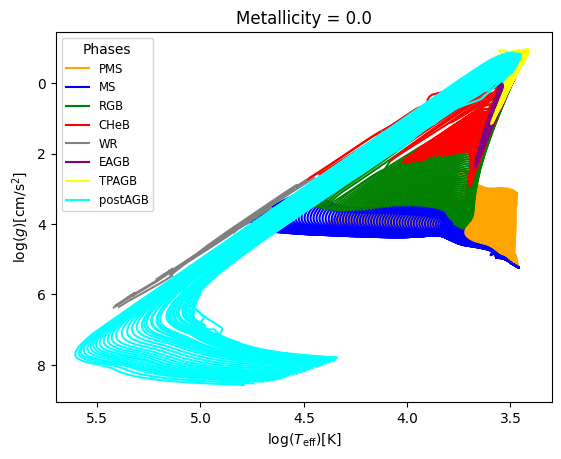

In [23]:
iso_handler = Iso_data_handler(path_to_data, 
                              ['log10_isochrone_age_yr', 'log_Teff', 'log_g', 'phase', 'metallicity', 'star_mass', 'log_R'], 
                              physical_model, reclassify=True)

iso_df = iso_handler.get_isochrone_dataframe()
display(iso_df)
data_visualiser = Data_visualiser(iso_df, physical_model)
data_visualiser.plot_Kiel([], [0.0])

,log10_isochrone_age_yr,log_Teff,log_g,phase,metallicity,star_mass,log_R
0,5.0,4.494412,4.346972,0.0,-0.25,13.584360,0.610679
1,5.0,4.497517,4.345776,0.0,-0.25,13.765512,0.614753
2,5.0,4.500556,4.344580,0.0,-0.25,13.942887,0.618755
3,5.0,4.504040,4.343050,0.0,-0.25,14.591712,0.624670
4,5.0,4.507576,4.341483,0.0,-0.25,15.426062,0.631187
...,...,...,...,...,...,...,...
630600,10.3,3.602322,1.827453,3.0,0.50,0.866616,1.274247
630601,10.3,3.600999,1.809405,3.0,0.50,0.866614,1.283270
630602,10.3,3.599710,1.791489,3.0,0.50,0.866612,1.292228
630603,10.3,3.598418,1.773621,3.0,0.50,0.866610,1.301161


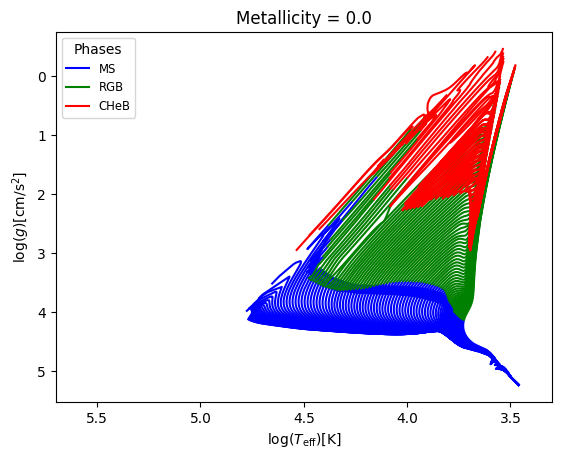

In [24]:
phase_filtered_iso_df = Data_preparator.filter_data(iso_df, {'phase':[0, 2, 3]})
display(phase_filtered_iso_df)
data_visualiser_phase_filtered = Data_visualiser(phase_filtered_iso_df, physical_model)
data_visualiser_phase_filtered.plot_Kiel([], [0.0])

In [25]:
print_all_uniques(phase_filtered_iso_df)

log10_isochrone_age_yr  : Range : 5.0 - 10.3, Mean : 8.1154, Median : 8.15

log_Teff  : Range : 3.34 - 5.3788, Mean : 4.0283, Median : 3.9761

log_g  : Range : -1.08 - 6.2594, Mean : 3.5075, Median : 3.8521

Values in phase column : 0.0, 2.0, 3.0 

Values in metallicity column : -0.25, -0.5, -0.75, -1.0, -1.25, -1.5, -1.75, -2.0, -2.5, -3.0, -3.5, -4.0, 0.0, 0.25, 0.5 

star_mass  : Range : 0.1 - 298.5448, Mean : 11.4145, Median : 2.8996

log_R  : Range : -1.0 - 3.1298, Mean : 0.735, Median : 0.7005



In [26]:
X_train, X_ivs, y_train, y_ivs, categories_train, categories_ivs = \
    Data_preparator.split_data(phase_filtered_iso_df, x_cols=['log10_isochrone_age_yr', 'log_Teff', 'log_g', 'metallicity'], 
                               y_cols=['star_mass', 'log_R'], categories_cols=['phase'], random_state=12, print_stats=True)

print(X_train.shape, X_ivs.shape)
print(y_train.shape, y_ivs.shape)

Training set statistics:
Range in train data for the star_mass parameter : 0.0999979840073621 - 298.5447575808816
Median value in train data for the star_mass parameter: 2.900660435695107
Mean value in train data for the star_mass parameter: 11.448959764246645

Range in train data for the log_R parameter : -0.9974628481553472 - 3.129269620812593
Median value in train data for the log_R parameter: 0.7005259212303901
Mean value in train data for the log_R parameter: 0.7346615625058007

Testing set statistics:
Range in test data for the star_mass parameter : 0.0999984244466985 - 295.93050489035244
Median value in test data for the star_mass parameter: 2.89581954298918
Mean value in test data for the star_mass parameter: 11.31127918999169

Range in test data for the log_R parameter : -0.9974747647513328 - 3.1297545143214007
Median value in test data for the log_R parameter: 0.700308157259431
Mean value in test data for the log_R parameter: 0.7362027655401773

(472953, 4) (157652, 4)
(47295

## Model training

### Linear regression

In [27]:
lr_evaluator = Model_evaluator("linear_regression", path=path_to_results, physical_model=physical_model, output_parameters=output_parameters)


scale_standard train data :
Performing K-fold...
Split 1 X_train [[ 7.15        3.53089845  0.15829325  0.5       ]
 [ 8.2         3.89917649  2.70415485 -1.        ]
 [ 7.8         3.94176332  2.27404942 -2.        ]
 ...
 [10.05        3.63306806  5.06081841 -3.        ]
 [10.1         3.63517608  4.85026786 -1.5       ]
 [ 7.6         4.34799155  3.56572608 -4.        ]]
X_train_scaled [[-0.74966014 -1.43942188 -2.75434164  1.40814104]
 [ 0.06732518 -0.37487749 -0.66099847  0.28021372]
 [-0.24390732 -0.25177601 -1.01465408 -0.47173783]
 ...
 [ 1.5067755  -1.14409043  1.27677598 -1.22368938]
 [ 1.54567956 -1.13799698  1.10365009 -0.09576206]
 [-0.39952358  0.92246718  0.04743134 -1.97564093]]
2 X_train [[ 7.15        3.53089845  0.15829325  0.5       ]
 [ 8.2         3.89917649  2.70415485 -1.        ]
 [ 7.8         3.94176332  2.27404942 -2.        ]
 ...
 [10.05        3.63306806  5.06081841 -3.        ]
 [10.1         3.63517608  4.85026786 -1.5       ]
 [ 7.6         4.34799155

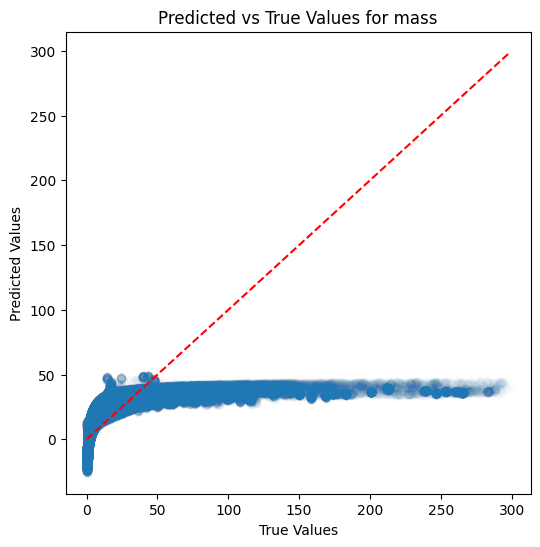

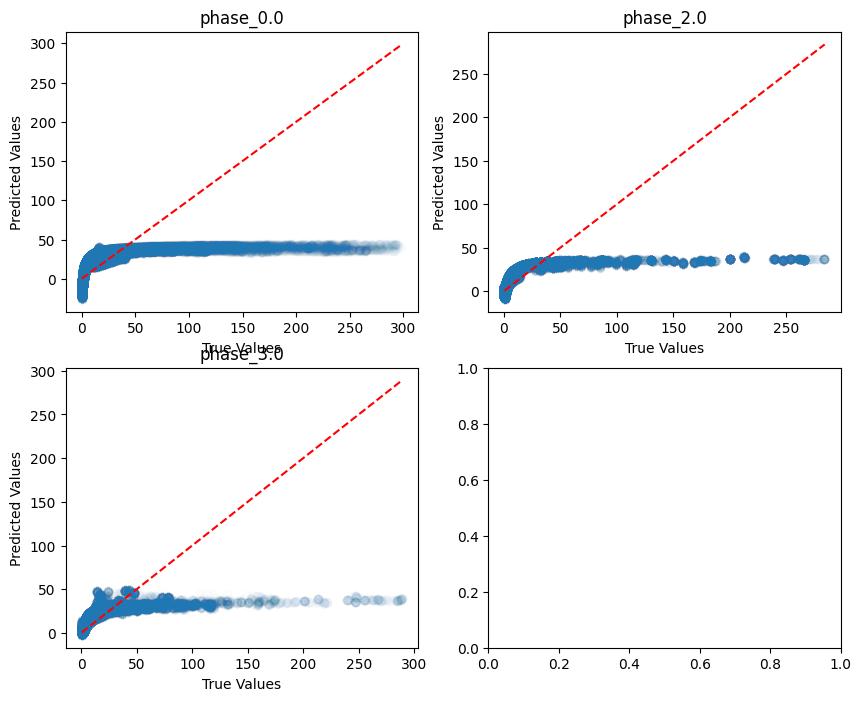

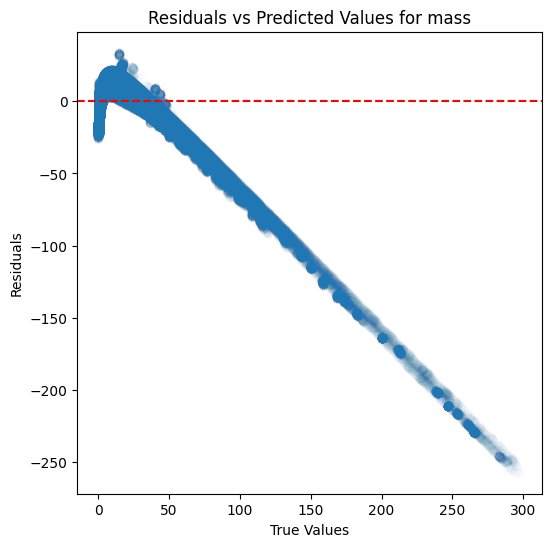

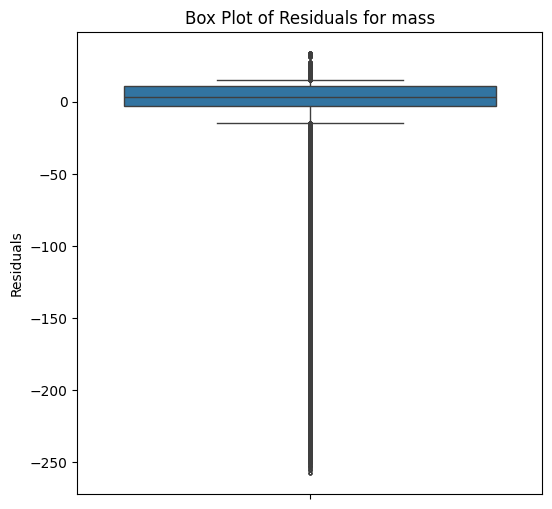

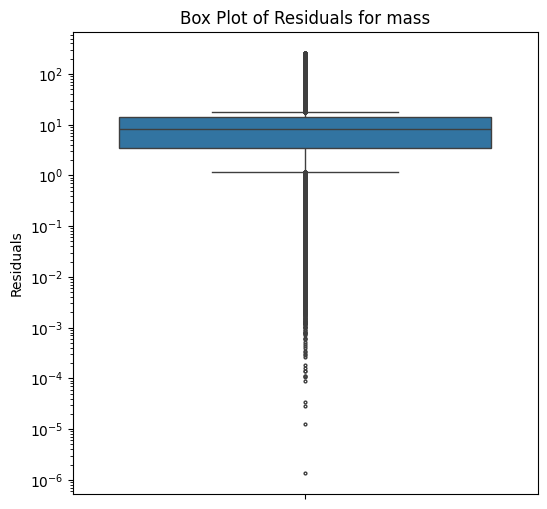

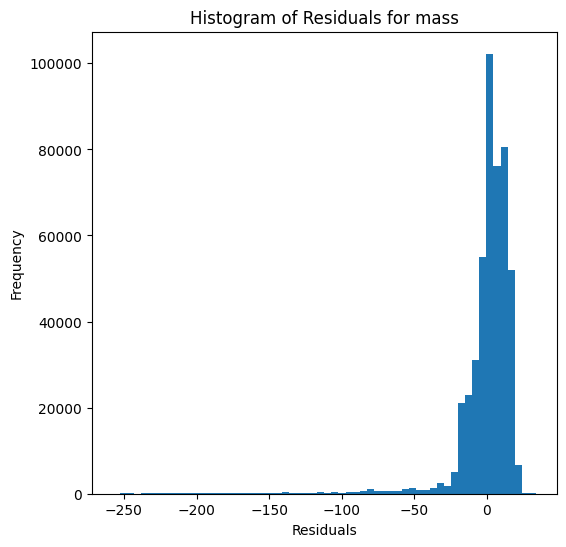

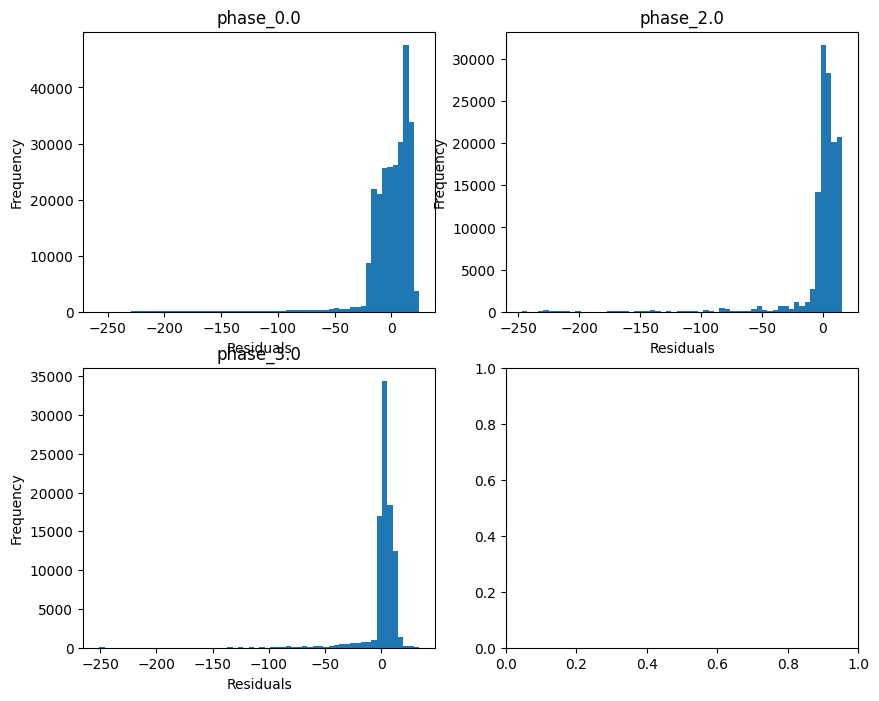

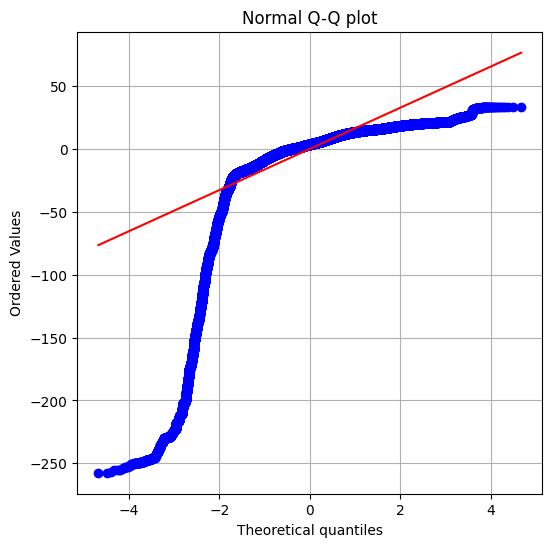

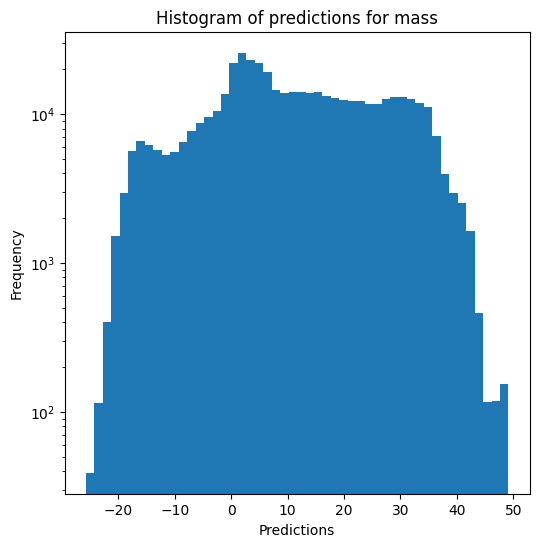

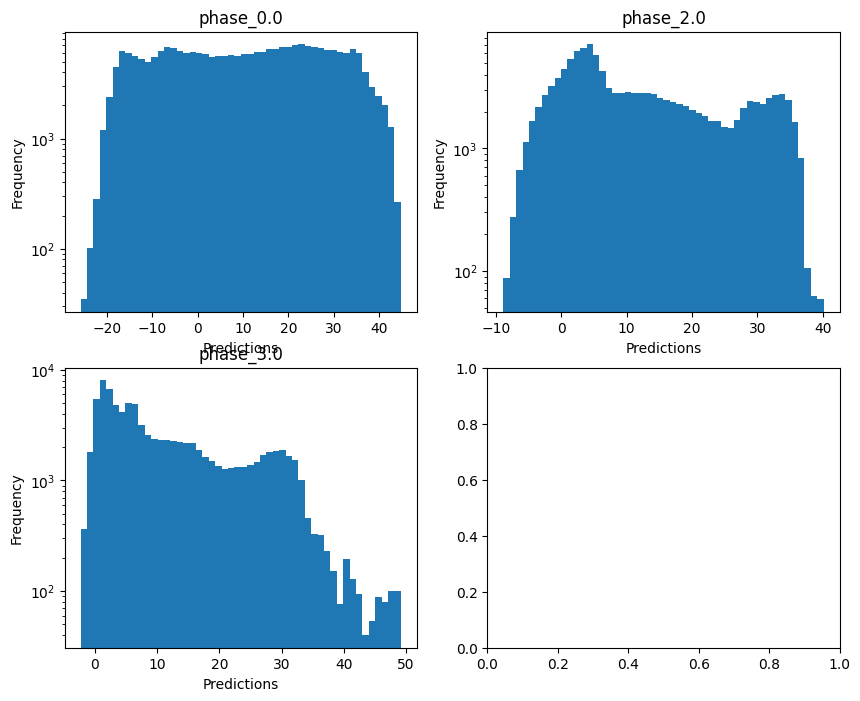

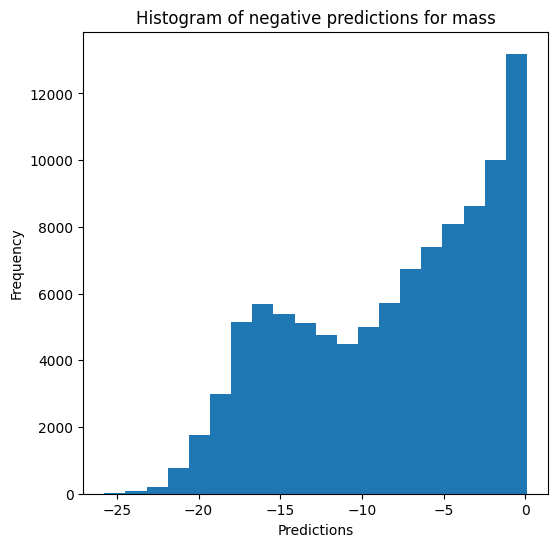


radius results for the phase category with a value of 0.0
  value range :  -0.9974628481553472 - 3.0827540579576227
  RVE :  0.9778146729622449
  RMSE :  0.08499169455949324
  MAE :  0.06644057676881099
  MedAE :  0.05247064416339825
  CORR :  0.9888944199376595
  MAX_ER :  0.4580776699591895
  Percentiles : 
    75th percentile :  0.09619903944974711
    90th percentile :  0.13469965074631446
    95th percentile :  0.15727958575247833
    99th percentile :  0.2505204276477324

radius results for the phase category with a value of 2.0
  value range :  0.0919862423867022 - 2.891706235288321
  RVE :  0.9679744997103389
  RMSE :  0.08841582971321496
  MAE :  0.05773662868810064
  MedAE :  0.03394437787641191
  CORR :  0.9838665758685898
  MAX_ER :  0.452908397569594
  Percentiles : 
    75th percentile :  0.0734989903749278
    90th percentile :  0.14129835891614617
    95th percentile :  0.19408078671038595
    99th percentile :  0.35002097849303965

radius results for the phase categor

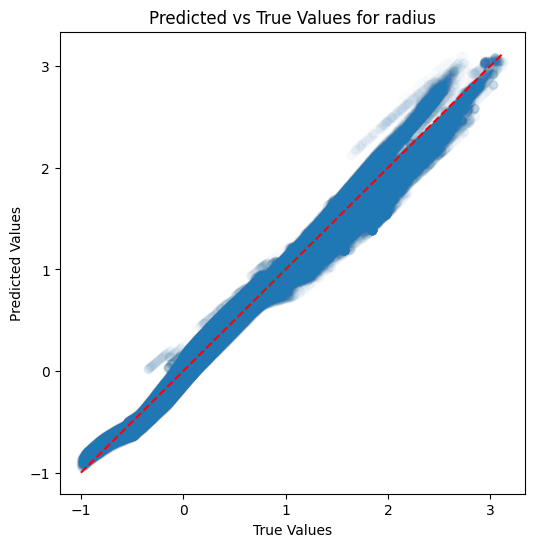

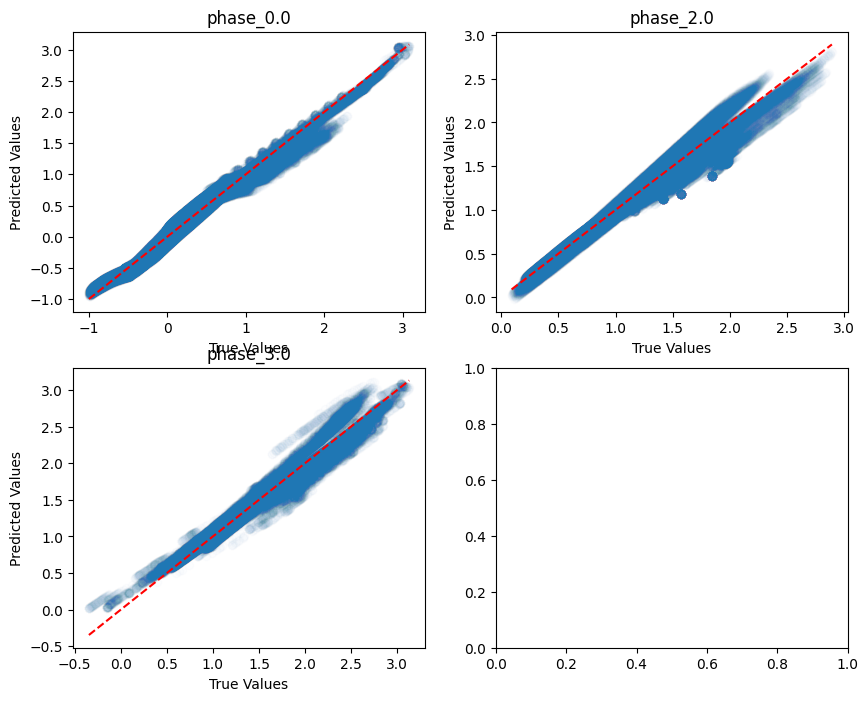

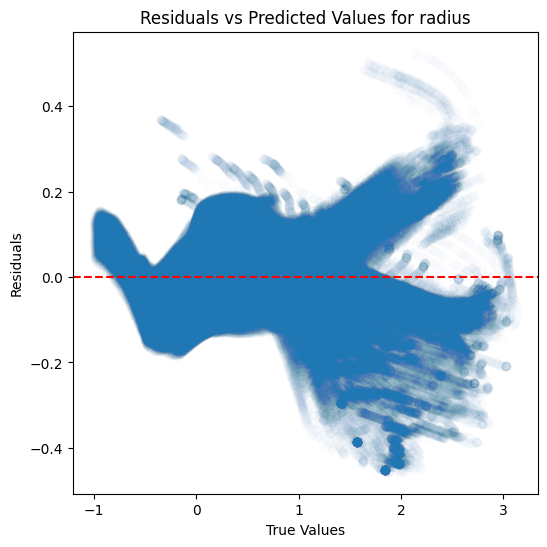

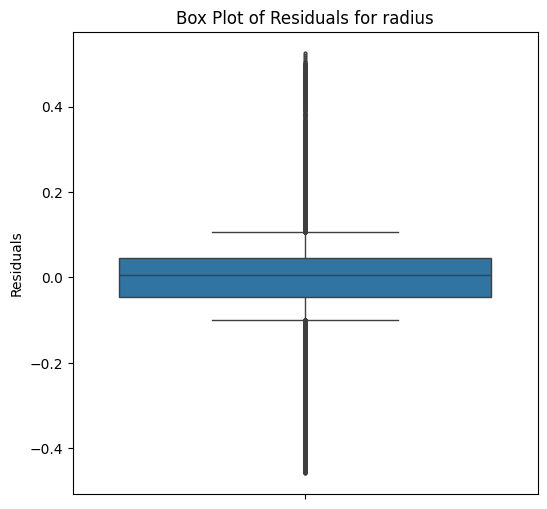

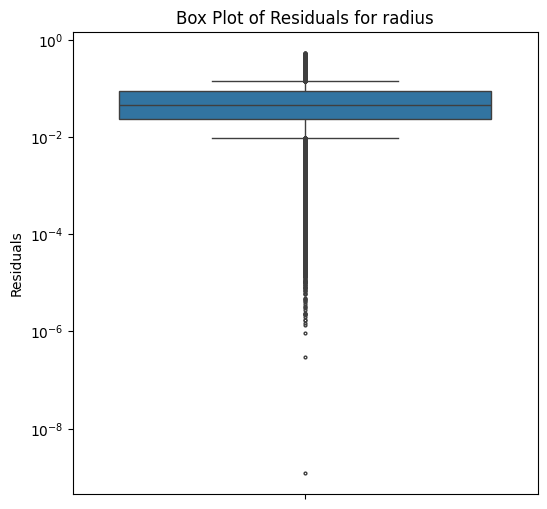

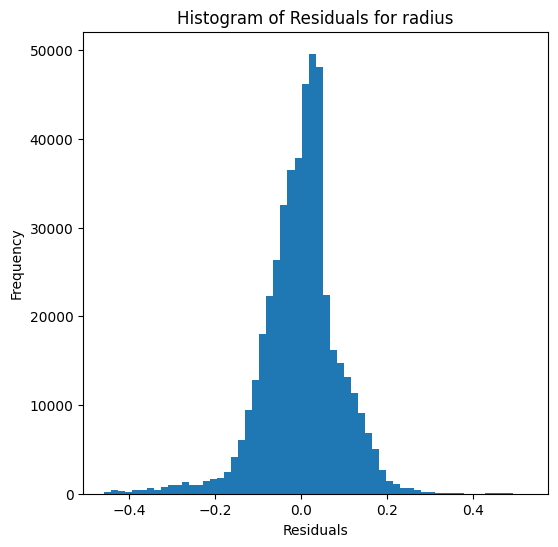

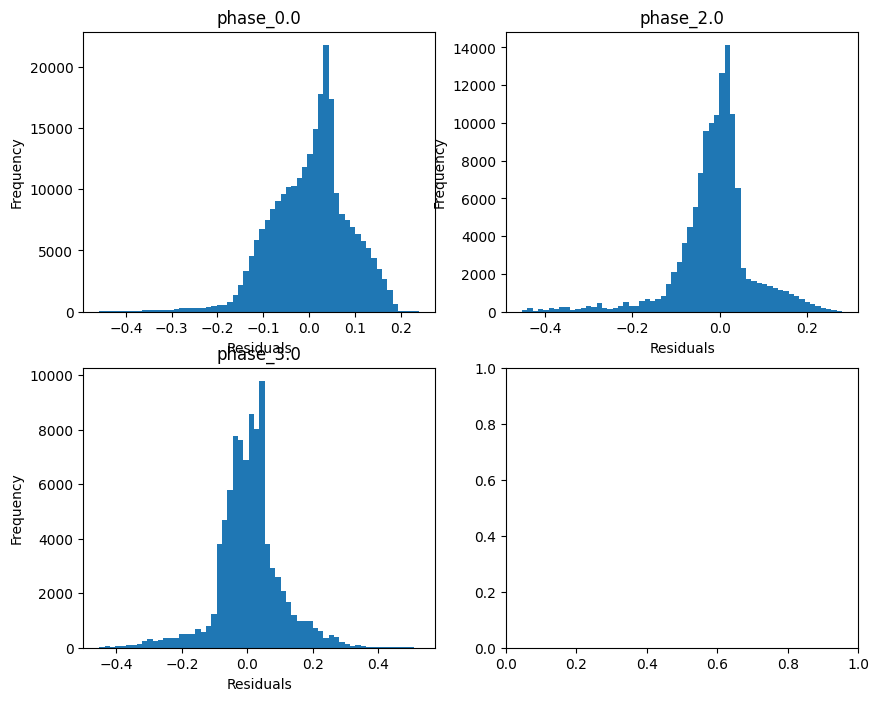

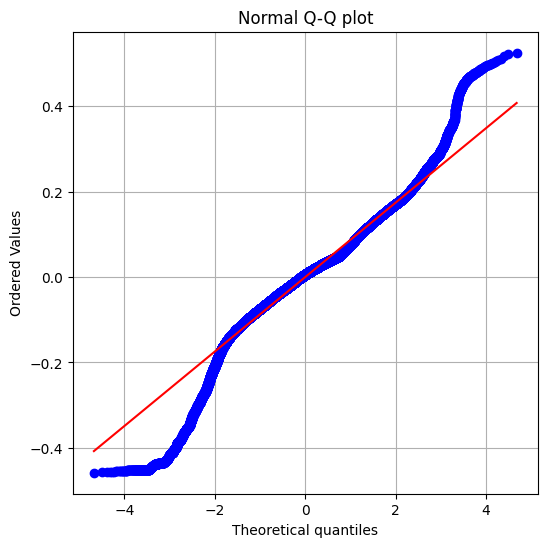

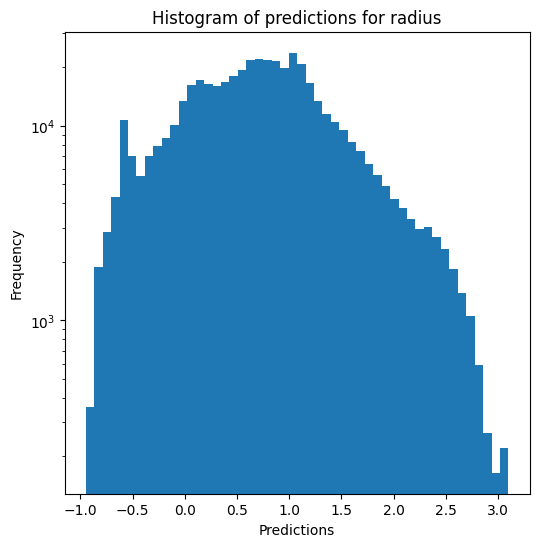

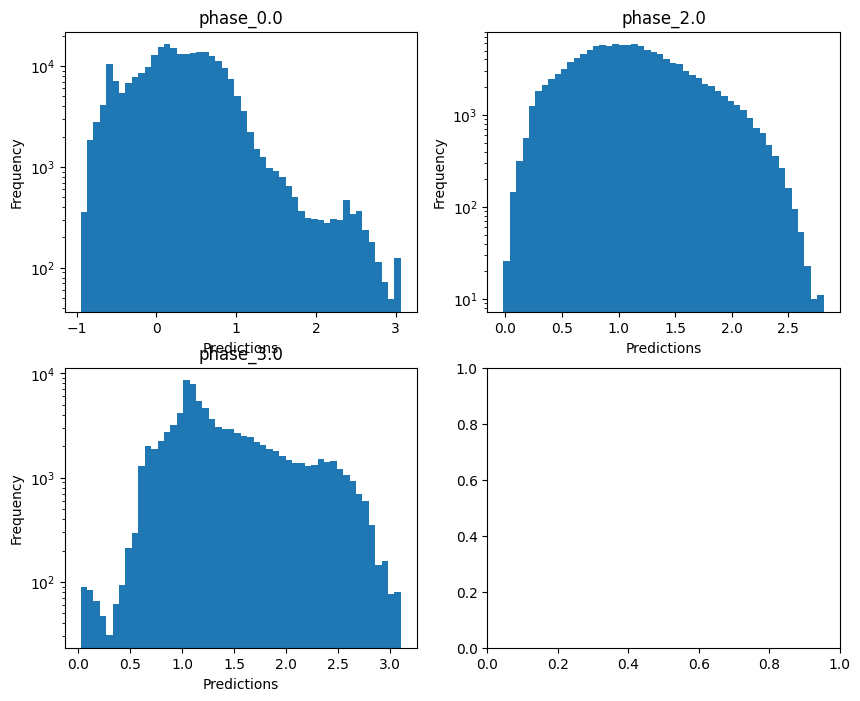

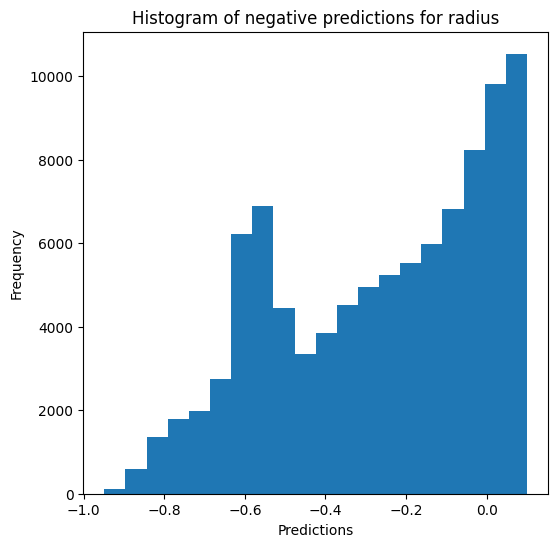

Saving predictions and results...


In [28]:
lr_evaluator.evaluate_Kfold_results(LinearRegression, X_train, y_train, categories_train, categories_name, path_to_predictions, tag, random_state=12, override=override, use_preds=use_preds, save=save, show=show, scaler_name=scaler_name) #, override=False, use_preds=True

### Decision tree

In [29]:
dt_evaluator = Model_evaluator("decision_tree", path=path_to_results, physical_model=physical_model, output_parameters=output_parameters)


scale_standard train data :
Performing K-fold...
Split 1 X_train [[ 7.15        3.53089845  0.15829325  0.5       ]
 [ 8.2         3.89917649  2.70415485 -1.        ]
 [ 7.8         3.94176332  2.27404942 -2.        ]
 ...
 [10.05        3.63306806  5.06081841 -3.        ]
 [10.1         3.63517608  4.85026786 -1.5       ]
 [ 7.6         4.34799155  3.56572608 -4.        ]]
X_train_scaled [[-0.74966014 -1.43942188 -2.75434164  1.40814104]
 [ 0.06732518 -0.37487749 -0.66099847  0.28021372]
 [-0.24390732 -0.25177601 -1.01465408 -0.47173783]
 ...
 [ 1.5067755  -1.14409043  1.27677598 -1.22368938]
 [ 1.54567956 -1.13799698  1.10365009 -0.09576206]
 [-0.39952358  0.92246718  0.04743134 -1.97564093]]
2 X_train [[ 7.15        3.53089845  0.15829325  0.5       ]
 [ 8.2         3.89917649  2.70415485 -1.        ]
 [ 7.8         3.94176332  2.27404942 -2.        ]
 ...
 [10.05        3.63306806  5.06081841 -3.        ]
 [10.1         3.63517608  4.85026786 -1.5       ]
 [ 7.6         4.34799155

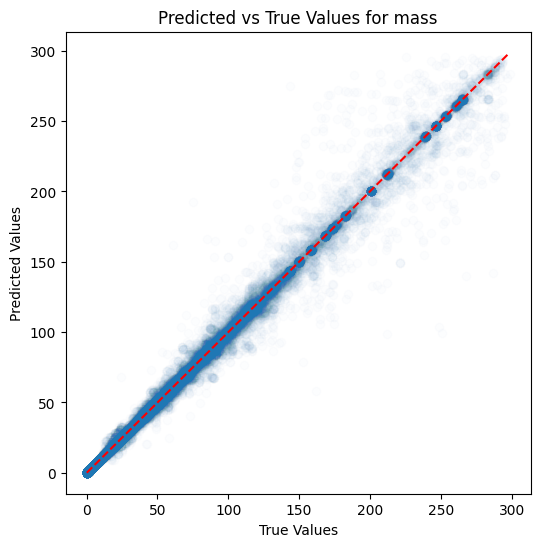

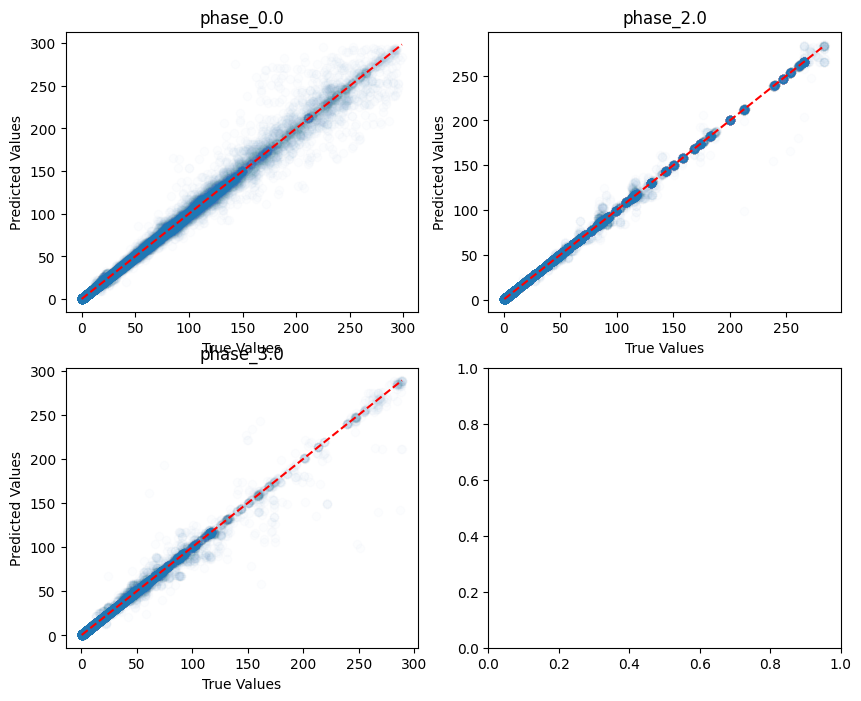

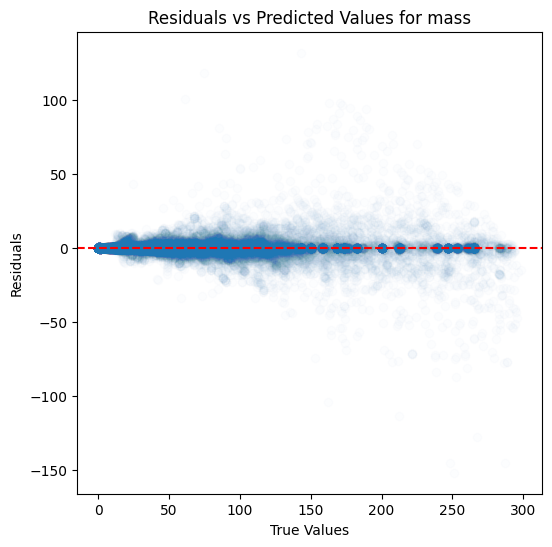

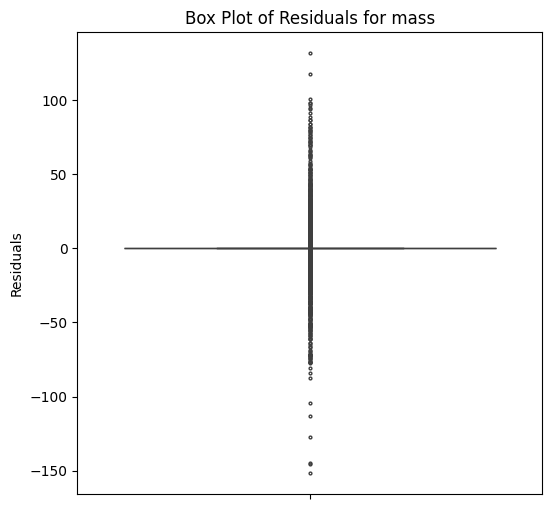

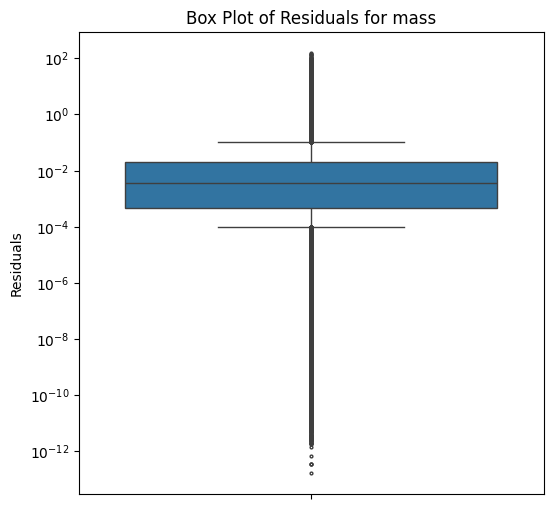

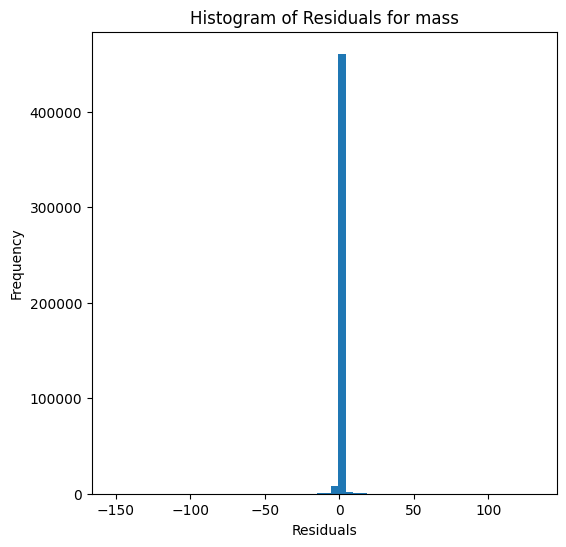

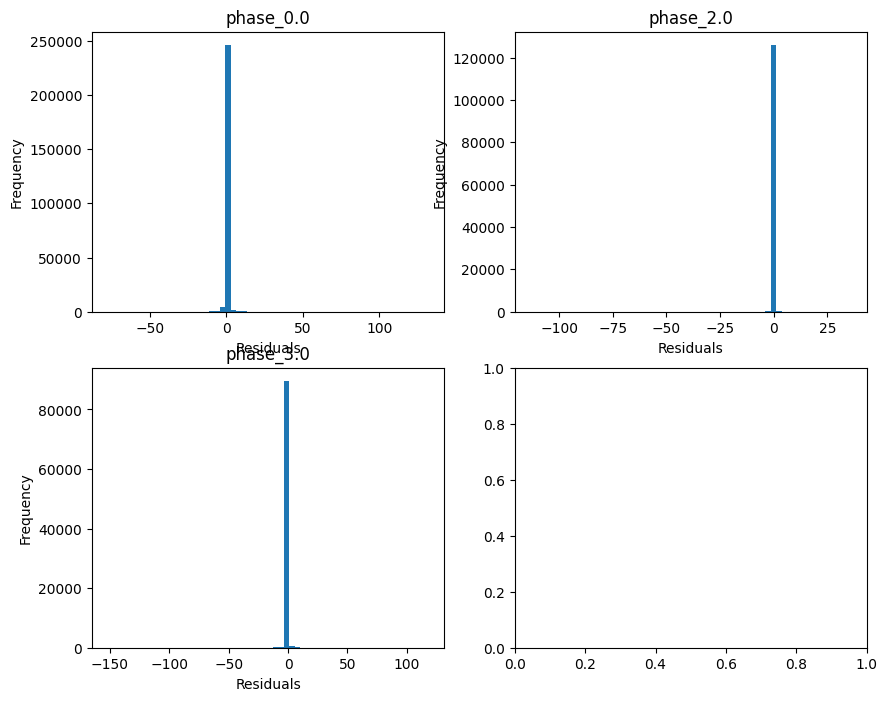

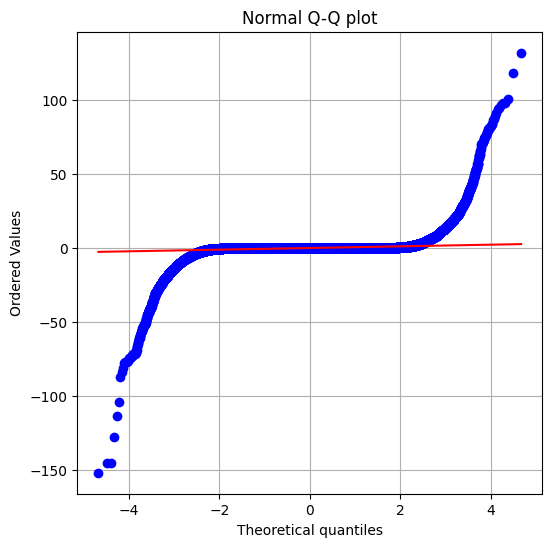

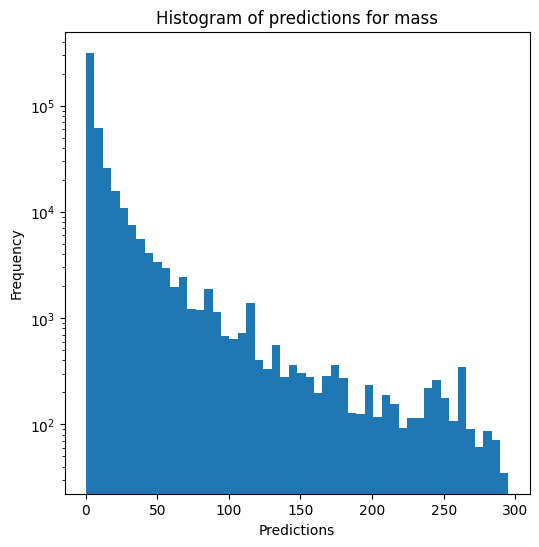

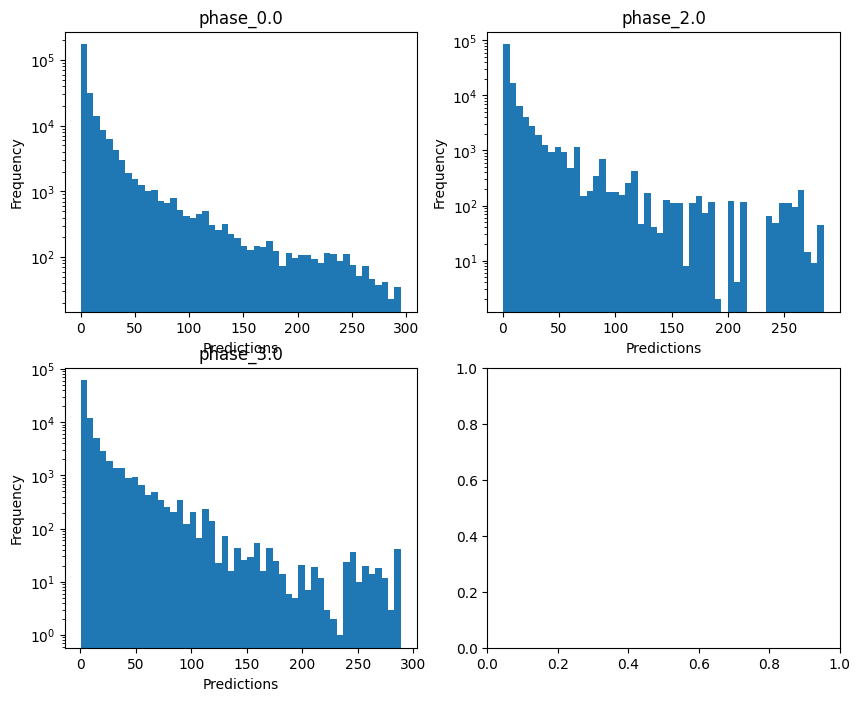

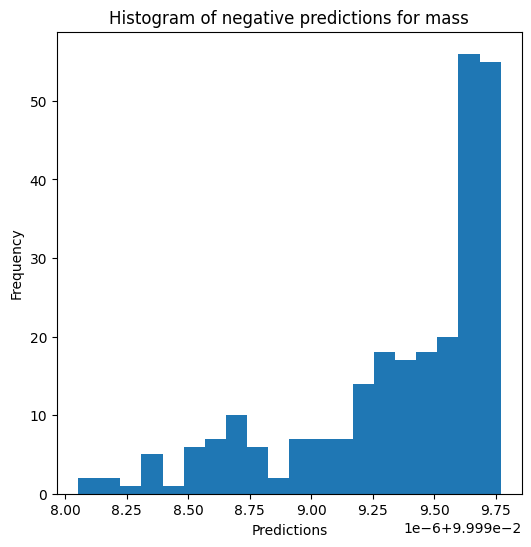


radius results for the phase category with a value of 0.0
  value range :  -0.9974628481553472 - 3.0827540579576227
  RVE :  0.9997812436032391
  RMSE :  0.008435688012607835
  MAE :  0.004604492310135729
  MedAE :  0.0026291670508375997
  CORR :  0.9998906664946047
  MAX_ER :  0.4783497157713891
  Percentiles : 
    75th percentile :  0.005350777189289925
    90th percentile :  0.010280571681817785
    95th percentile :  0.015192904845933119
    99th percentile :  0.032233986879938614

radius results for the phase category with a value of 2.0
  value range :  0.0919862423867022 - 2.891706235288321
  RVE :  0.9995938384041673
  RMSE :  0.009896829407032579
  MAE :  0.006751447268614817
  MedAE :  0.005225576978209301
  CORR :  0.9997981813678157
  MAX_ER :  0.2478920369530373
  Percentiles : 
    75th percentile :  0.009074205230636512
    90th percentile :  0.01346201108754226
    95th percentile :  0.01663816179738919
    99th percentile :  0.03179714991486068

radius results for th

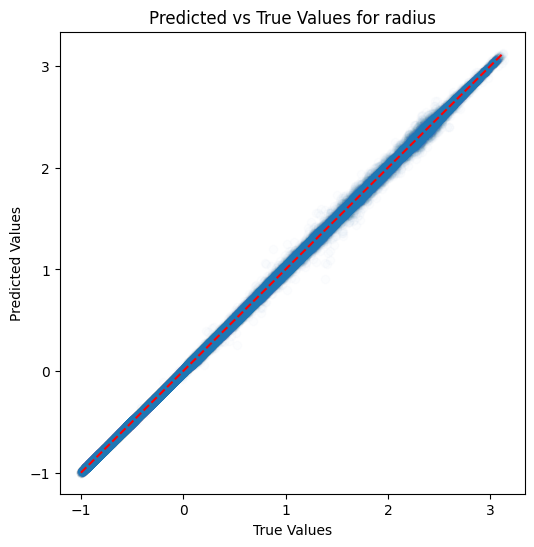

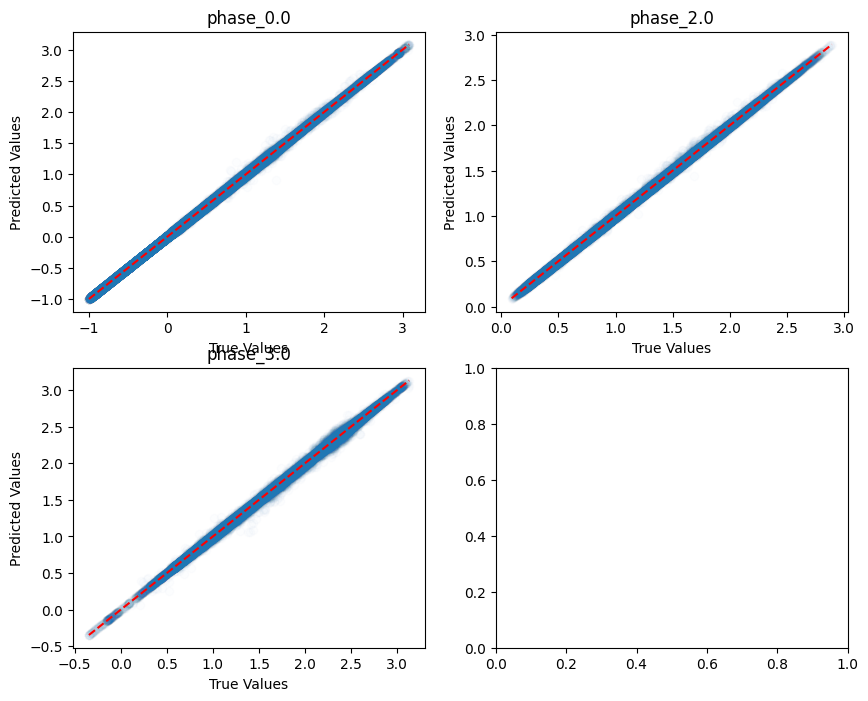

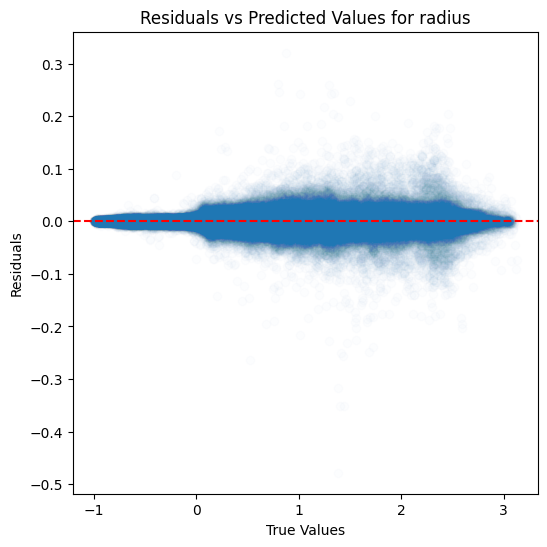

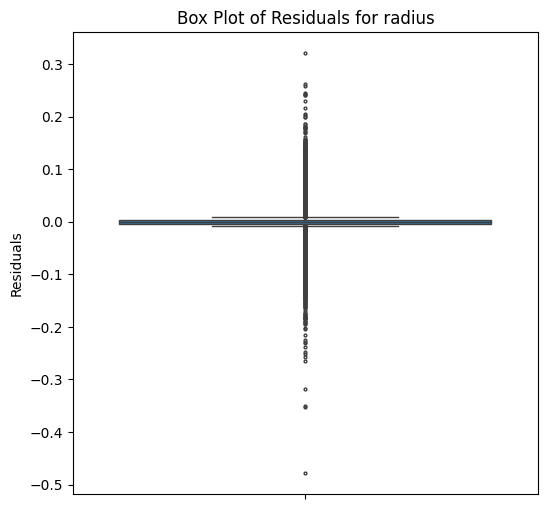

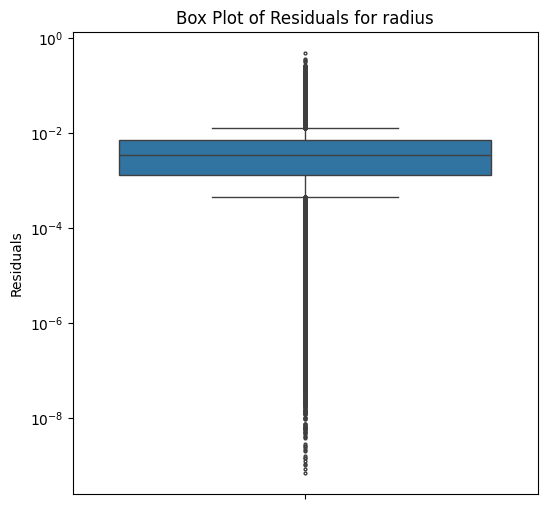

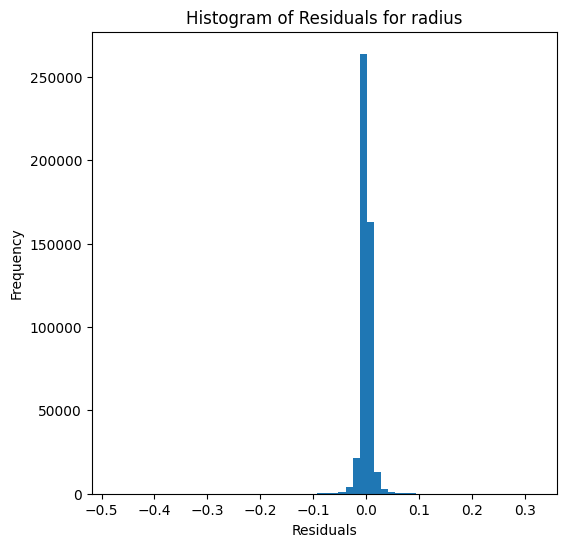

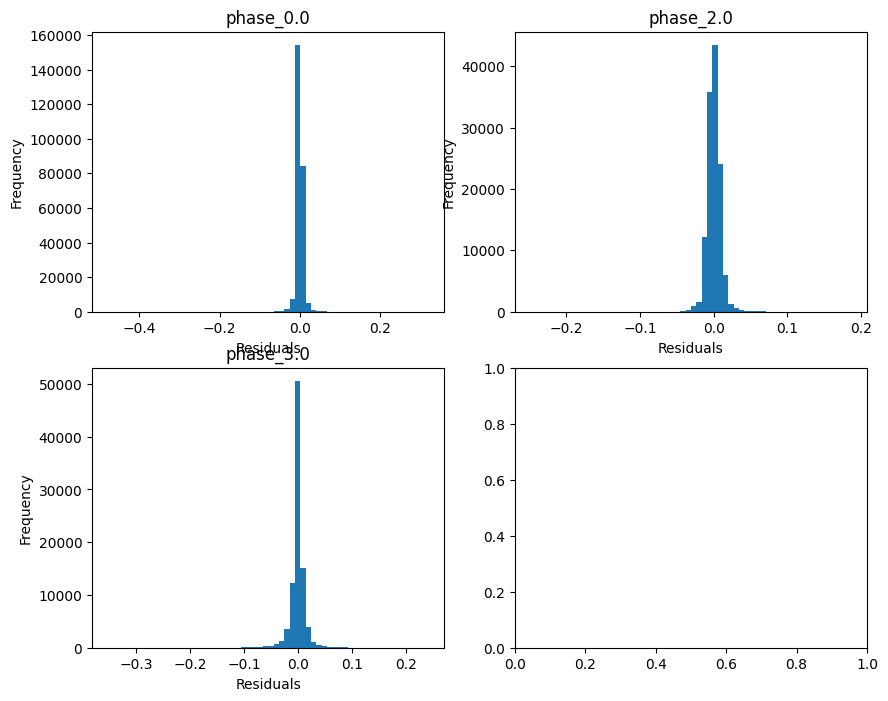

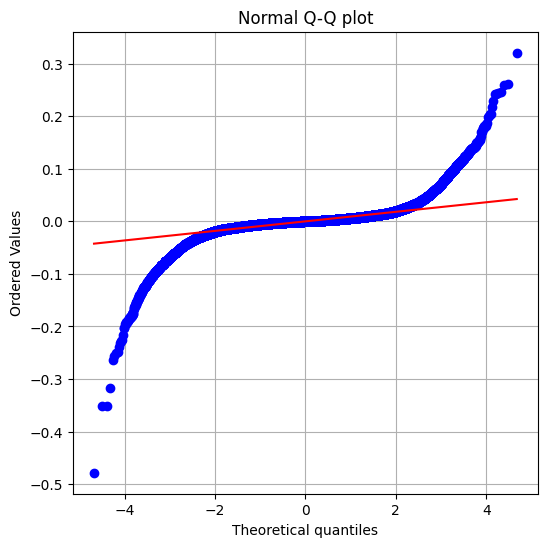

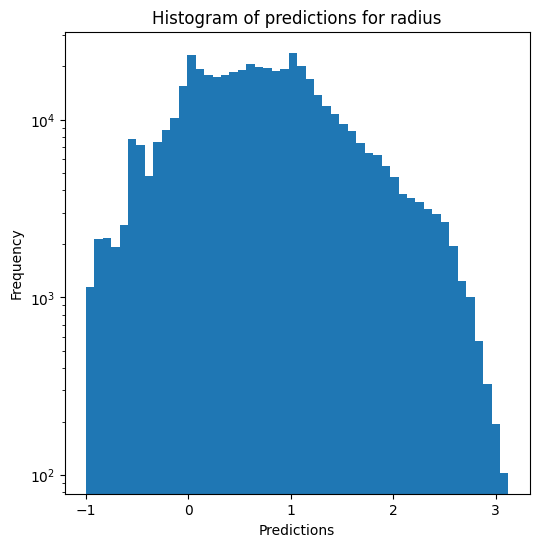

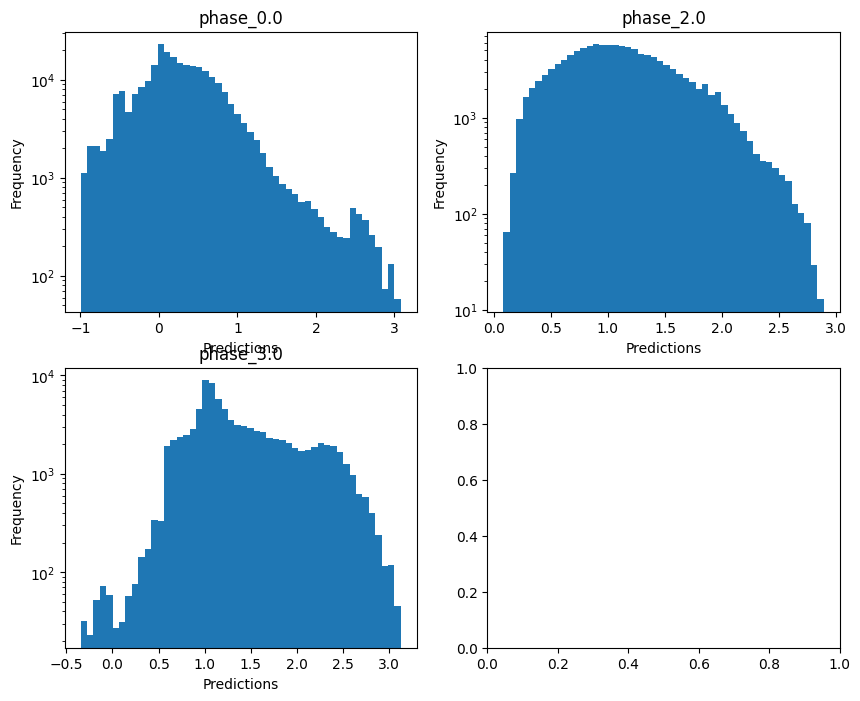

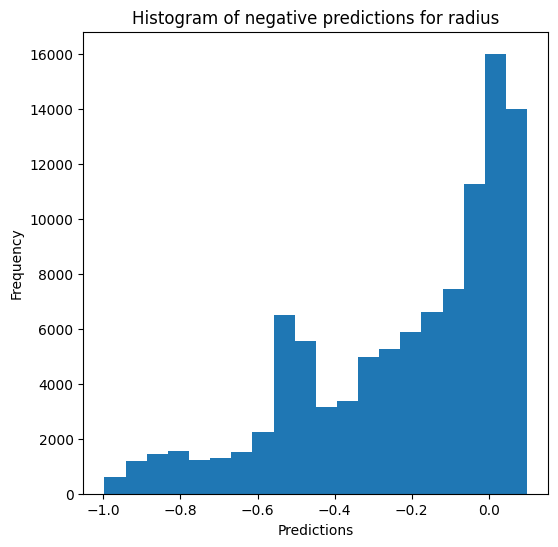

Saving predictions and results...


In [30]:
dt_evaluator.evaluate_Kfold_results(DecisionTreeRegressor, X_train, y_train, categories_train, categories_name, path_to_predictions, tag, random_state=12, override=override, use_preds=use_preds, save=save, show=show, scaler_name=scaler_name)

### K-nearest neighbours

In [31]:
knn_evaluator = Model_evaluator("KNN", path=path_to_results, physical_model=physical_model, output_parameters=output_parameters)


scale_standard train data :
Performing K-fold...
Split 1 X_train [[ 7.15        3.53089845  0.15829325  0.5       ]
 [ 8.2         3.89917649  2.70415485 -1.        ]
 [ 7.8         3.94176332  2.27404942 -2.        ]
 ...
 [10.05        3.63306806  5.06081841 -3.        ]
 [10.1         3.63517608  4.85026786 -1.5       ]
 [ 7.6         4.34799155  3.56572608 -4.        ]]
X_train_scaled [[-0.74966014 -1.43942188 -2.75434164  1.40814104]
 [ 0.06732518 -0.37487749 -0.66099847  0.28021372]
 [-0.24390732 -0.25177601 -1.01465408 -0.47173783]
 ...
 [ 1.5067755  -1.14409043  1.27677598 -1.22368938]
 [ 1.54567956 -1.13799698  1.10365009 -0.09576206]
 [-0.39952358  0.92246718  0.04743134 -1.97564093]]
2 X_train [[ 7.15        3.53089845  0.15829325  0.5       ]
 [ 8.2         3.89917649  2.70415485 -1.        ]
 [ 7.8         3.94176332  2.27404942 -2.        ]
 ...
 [10.05        3.63306806  5.06081841 -3.        ]
 [10.1         3.63517608  4.85026786 -1.5       ]
 [ 7.6         4.34799155

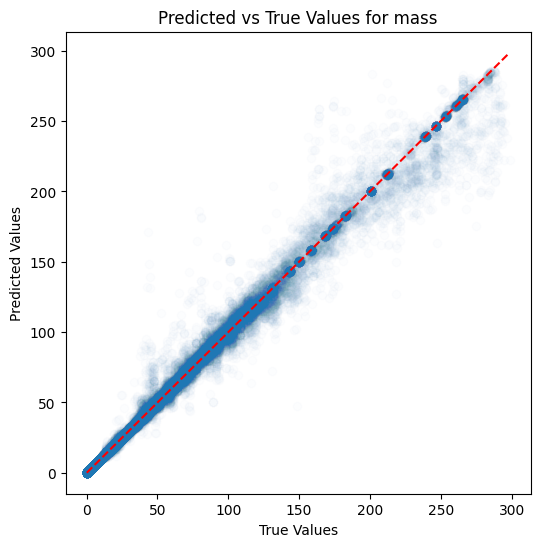

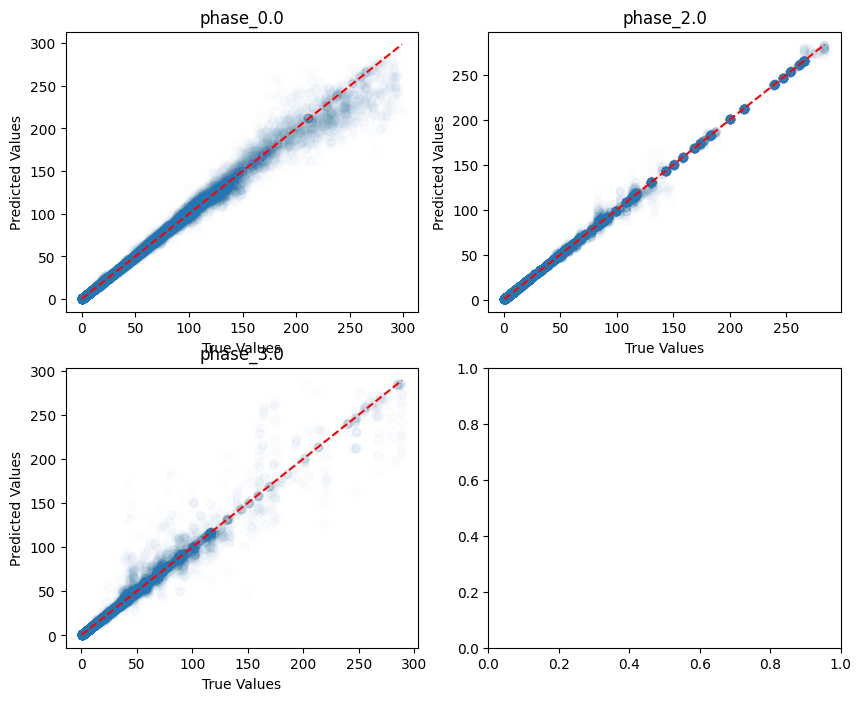

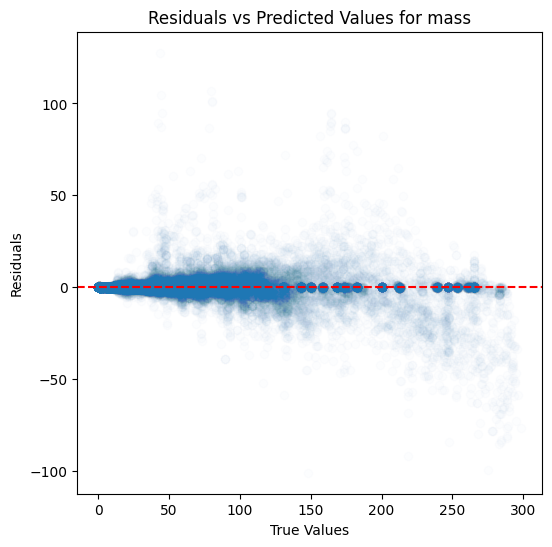

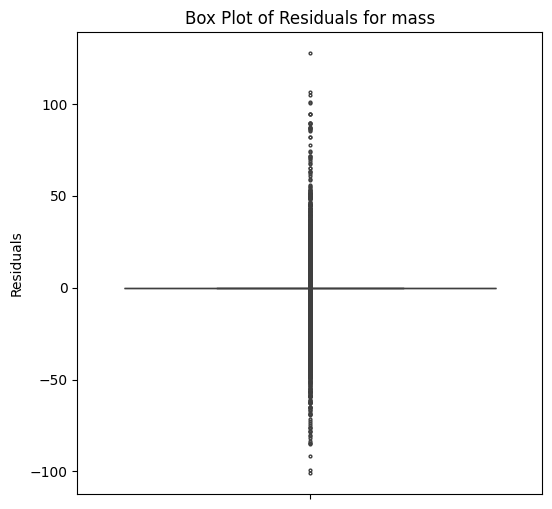

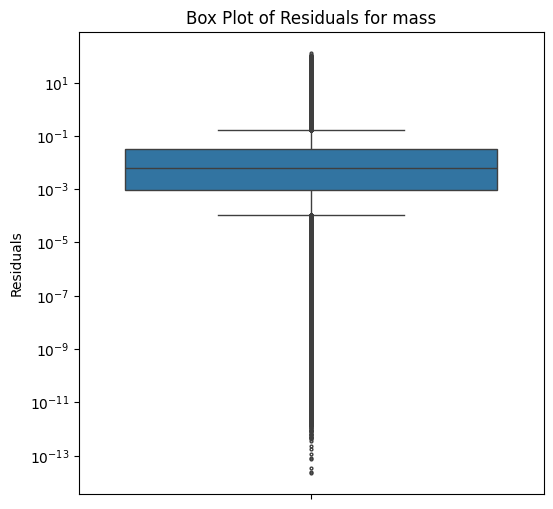

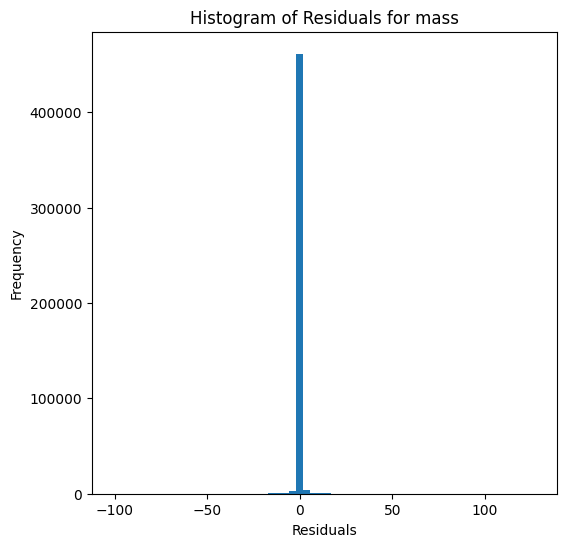

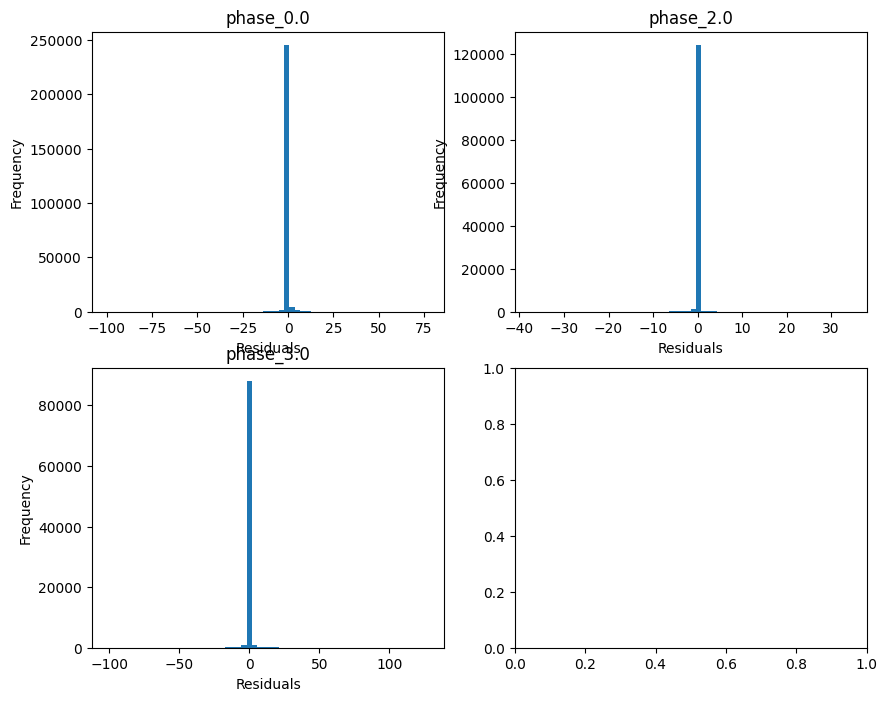

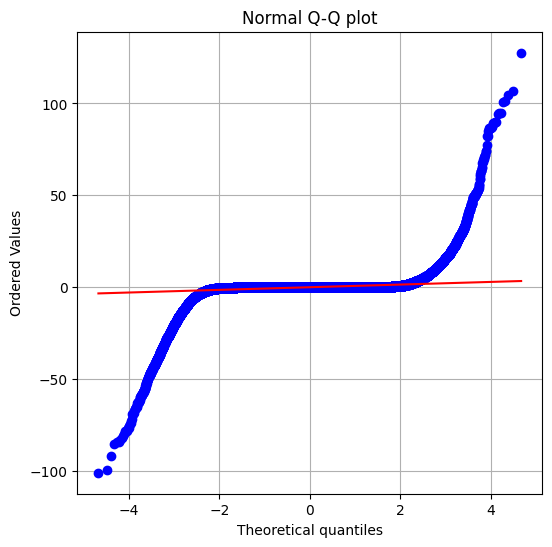

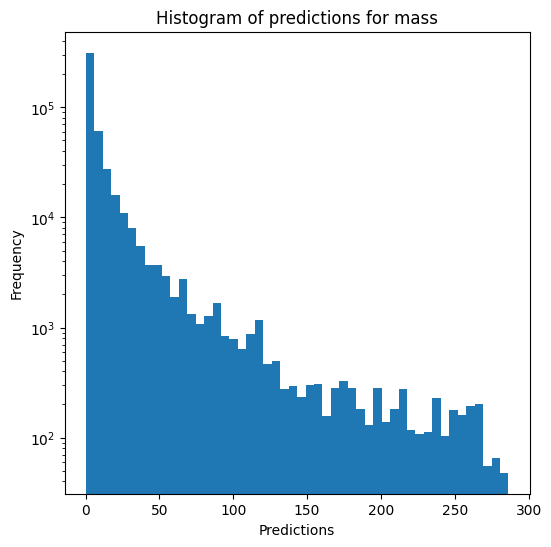

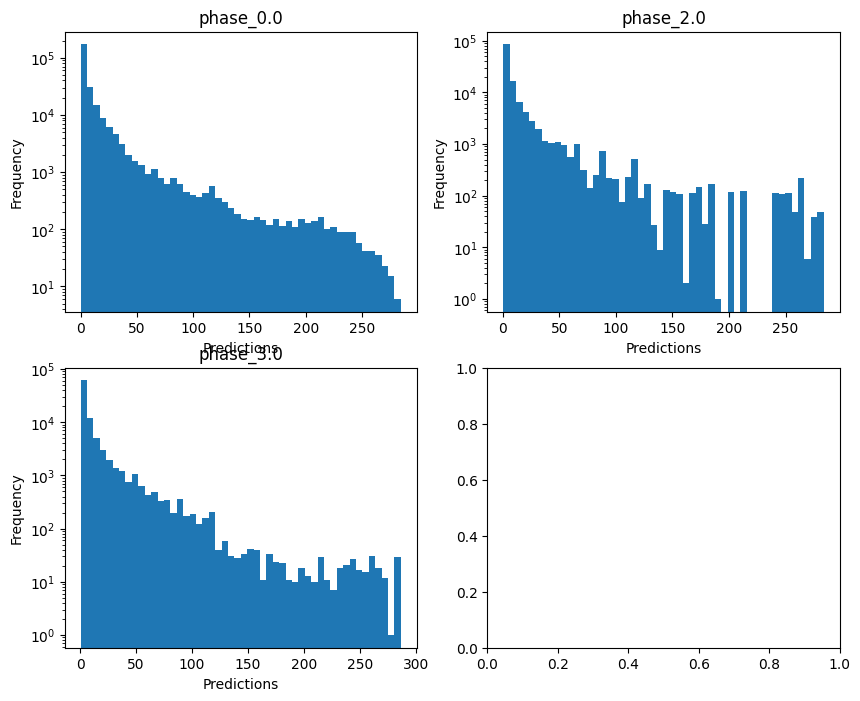


radius results for the phase category with a value of 0.0
  value range :  -0.9974628481553472 - 3.0827540579576227
  RVE :  0.9999041966145369
  RMSE :  0.0055823286327519785
  MAE :  0.003448330657797116
  MedAE :  0.002232775579215418
  CORR :  0.9999522108609485
  MAX_ER :  0.11636461602669157
  Percentiles : 
    75th percentile :  0.004256665672996214
    90th percentile :  0.007551586920192028
    95th percentile :  0.010682944374848258
    99th percentile :  0.02102560162008477

radius results for the phase category with a value of 2.0
  value range :  0.0919862423867022 - 2.891706235288321
  RVE :  0.9998902843052527
  RMSE :  0.005139787089011381
  MAE :  0.0036980002242870754
  MedAE :  0.0027391486002830145
  CORR :  0.9999451411322162
  MAX_ER :  0.07723242145030396
  Percentiles : 
    75th percentile :  0.004962144885519382
    90th percentile :  0.008135145888062745
    95th percentile :  0.010481505813775776
    99th percentile :  0.016159328552468502

radius results 

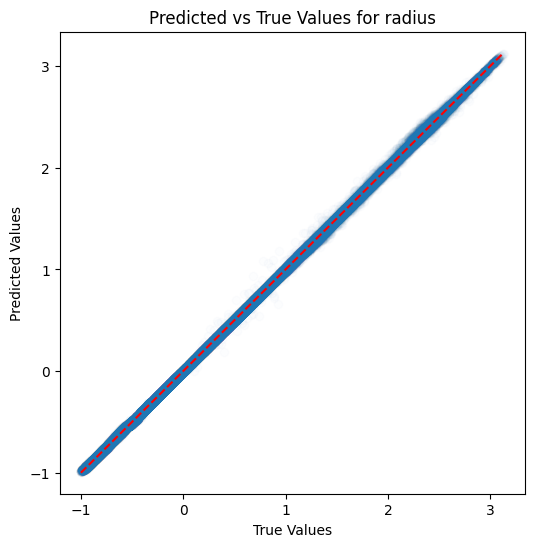

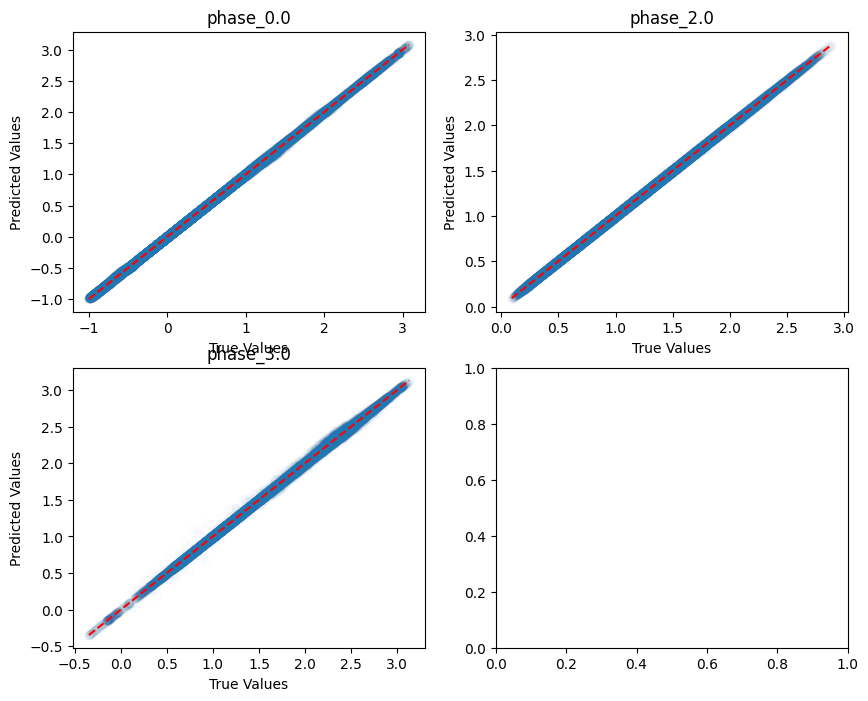

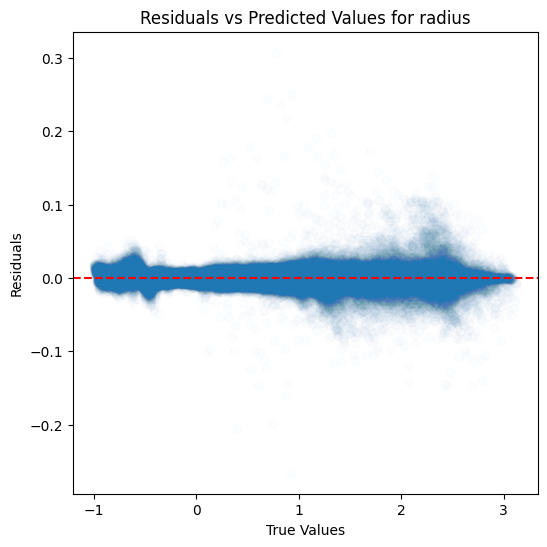

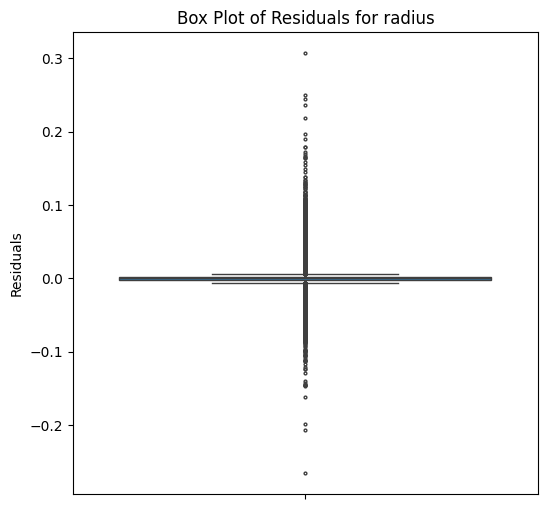

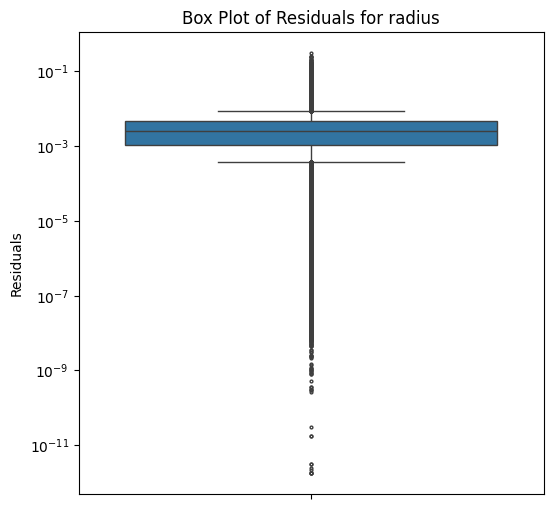

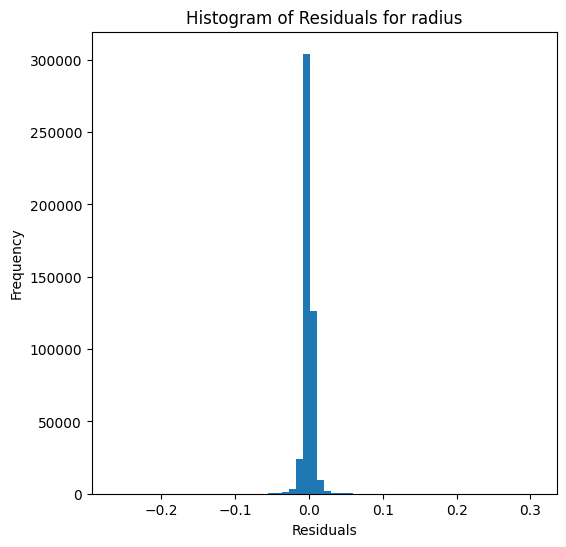

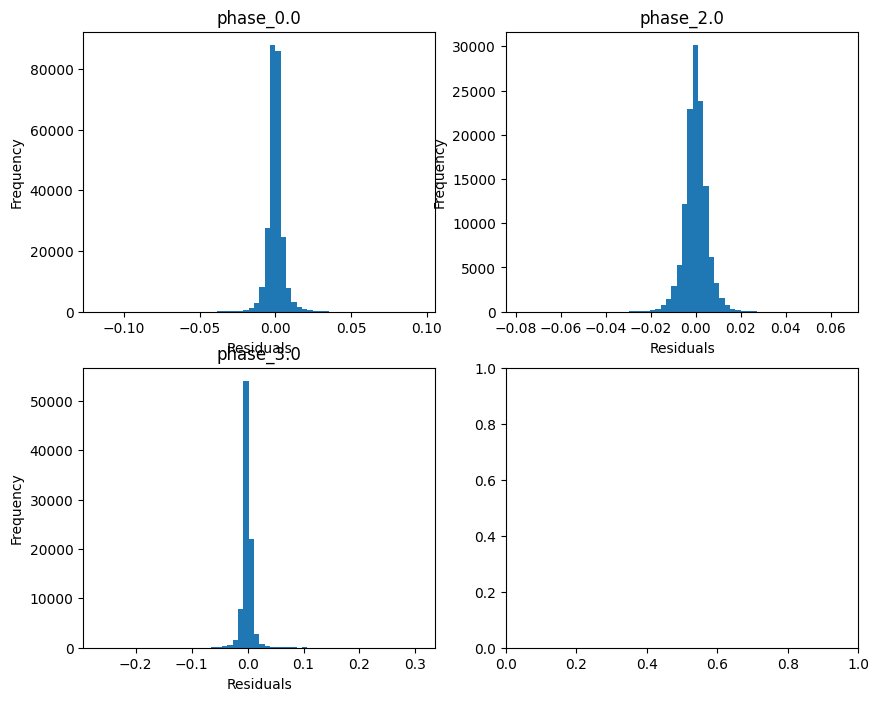

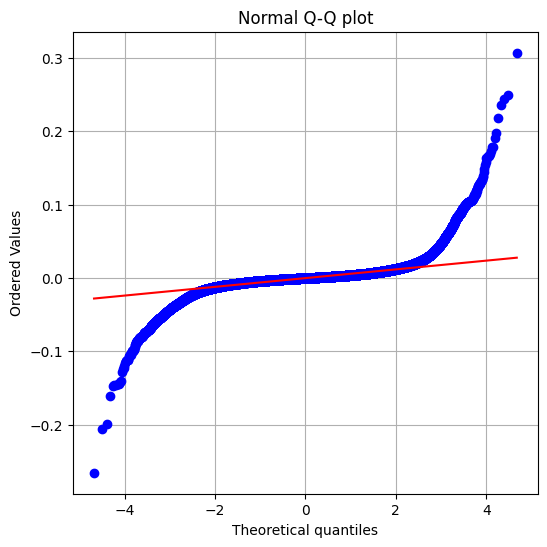

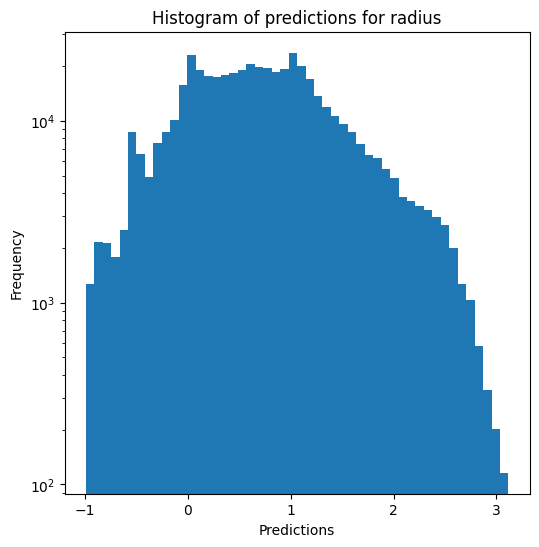

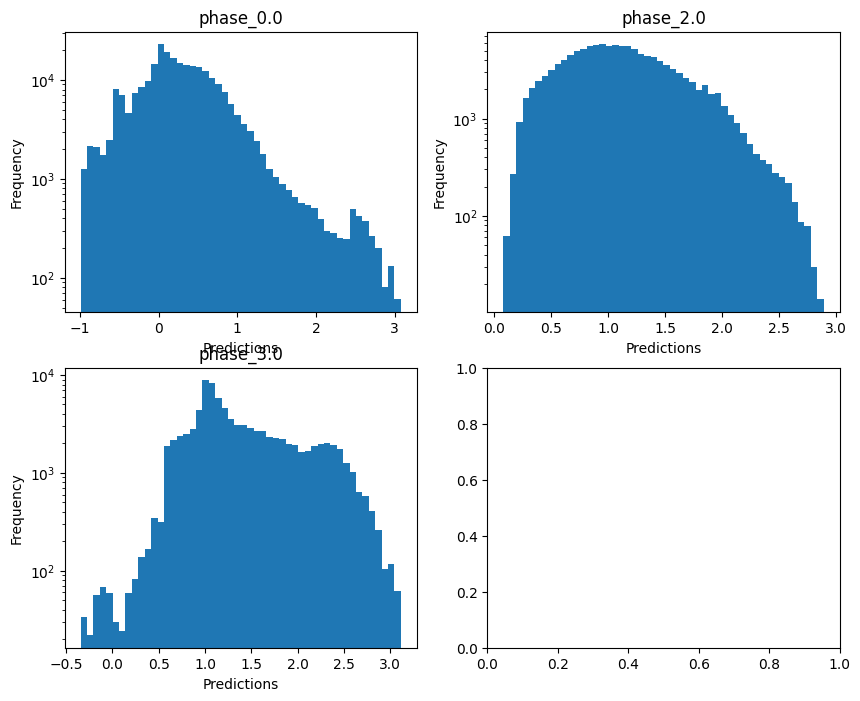

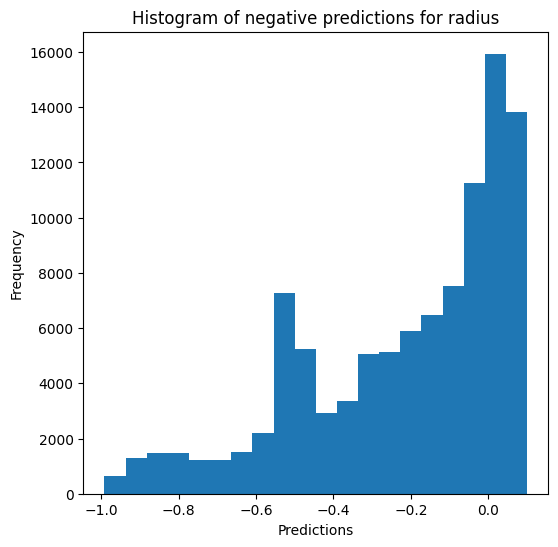

Saving predictions and results...


In [32]:
knn_evaluator.evaluate_Kfold_results(KNeighborsRegressor, X_train, y_train, categories_train, categories_name, path_to_predictions, tag, random_state=12, override=override, use_preds=use_preds, save=save, show=show, scaler_name=scaler_name)

### Random forests

In [33]:
rf_evaluator = Model_evaluator("random_forest", path=path_to_results, physical_model=physical_model, output_parameters=output_parameters)


scale_standard train data :
Performing K-fold...
Split 1 X_train [[ 7.15        3.53089845  0.15829325  0.5       ]
 [ 8.2         3.89917649  2.70415485 -1.        ]
 [ 7.8         3.94176332  2.27404942 -2.        ]
 ...
 [10.05        3.63306806  5.06081841 -3.        ]
 [10.1         3.63517608  4.85026786 -1.5       ]
 [ 7.6         4.34799155  3.56572608 -4.        ]]
X_train_scaled [[-0.74966014 -1.43942188 -2.75434164  1.40814104]
 [ 0.06732518 -0.37487749 -0.66099847  0.28021372]
 [-0.24390732 -0.25177601 -1.01465408 -0.47173783]
 ...
 [ 1.5067755  -1.14409043  1.27677598 -1.22368938]
 [ 1.54567956 -1.13799698  1.10365009 -0.09576206]
 [-0.39952358  0.92246718  0.04743134 -1.97564093]]
2 X_train [[ 7.15        3.53089845  0.15829325  0.5       ]
 [ 8.2         3.89917649  2.70415485 -1.        ]
 [ 7.8         3.94176332  2.27404942 -2.        ]
 ...
 [10.05        3.63306806  5.06081841 -3.        ]
 [10.1         3.63517608  4.85026786 -1.5       ]
 [ 7.6         4.34799155

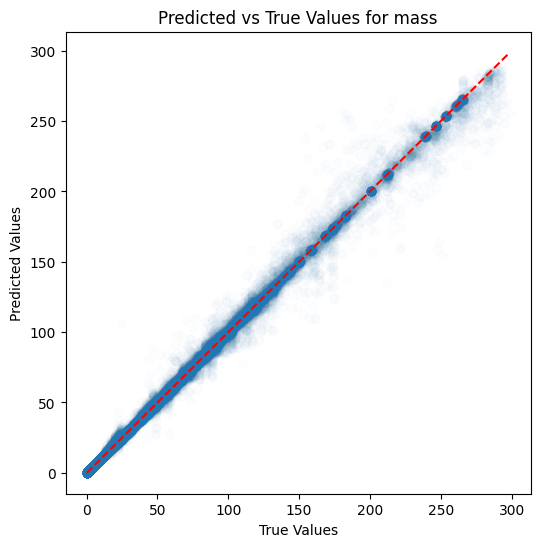

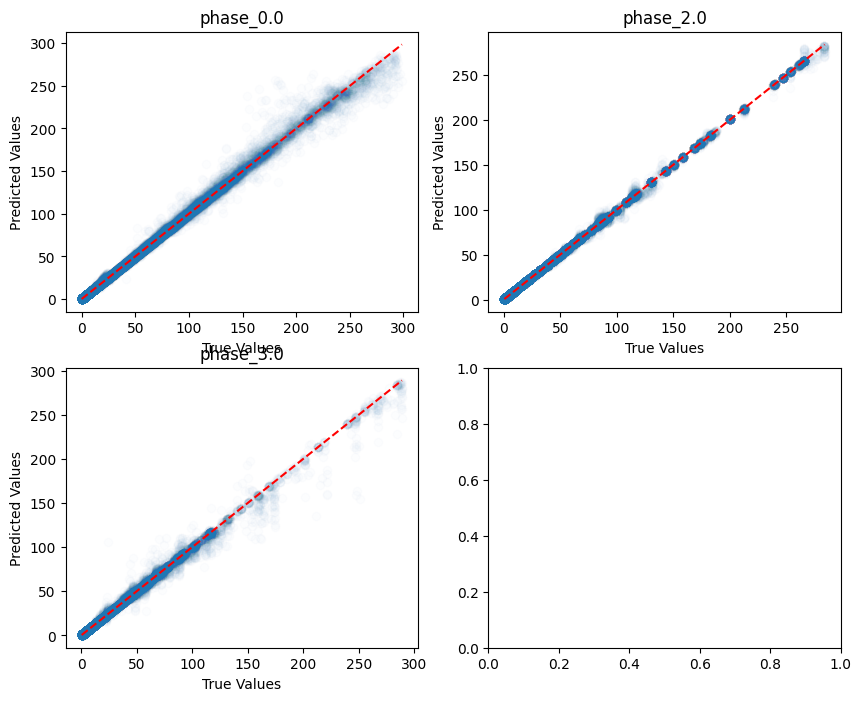

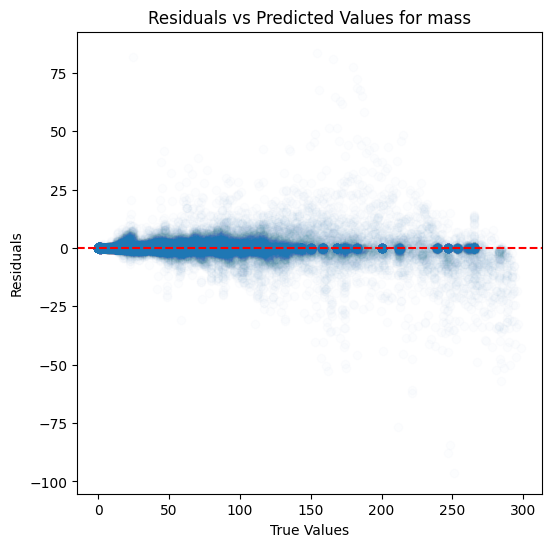

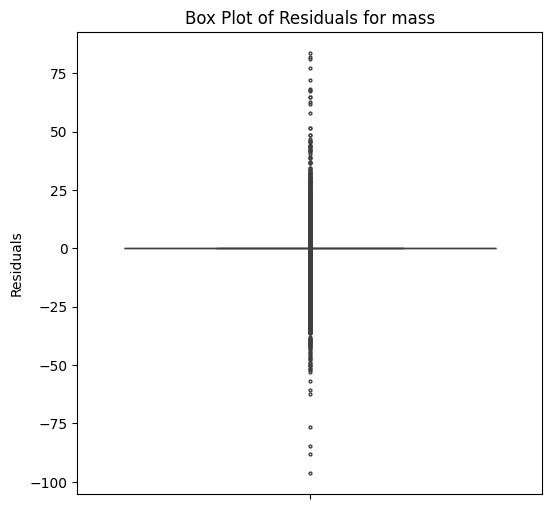

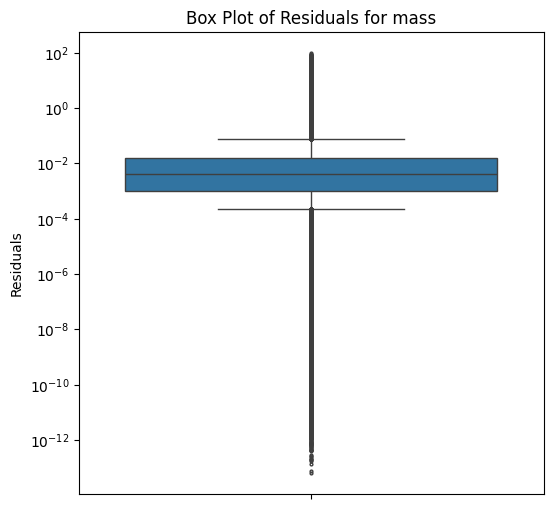

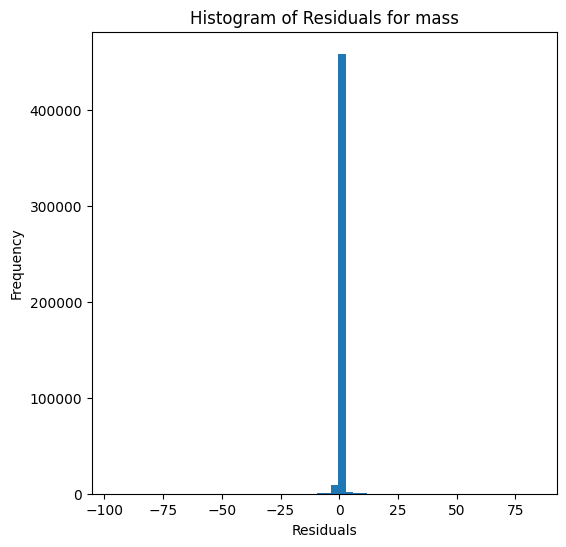

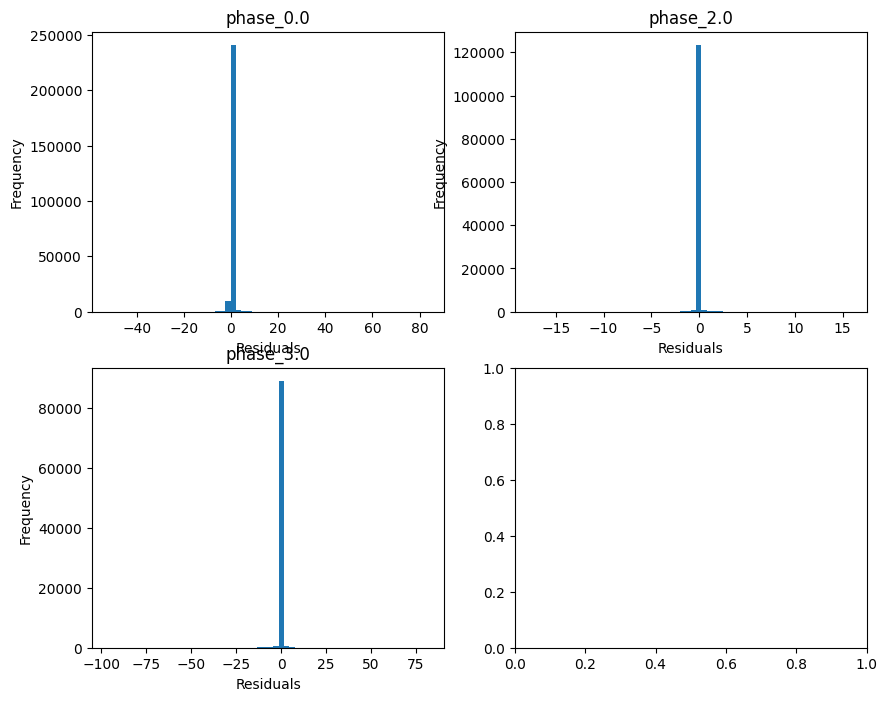

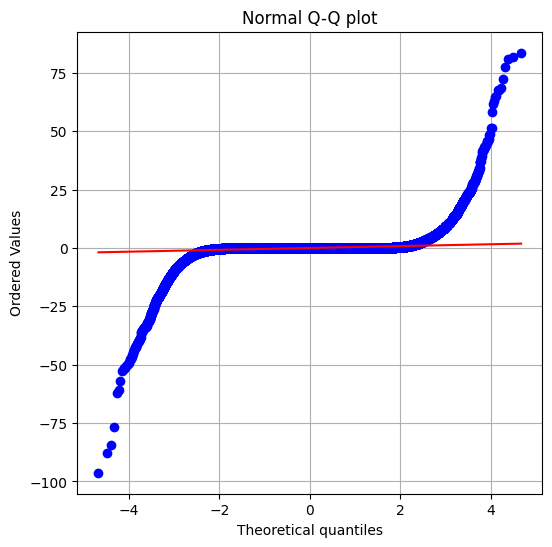

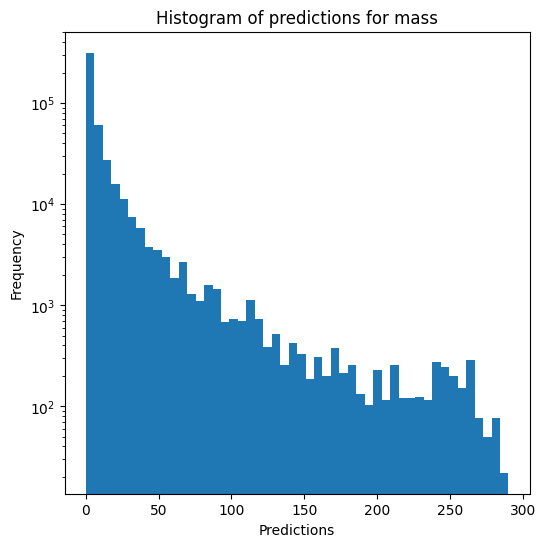

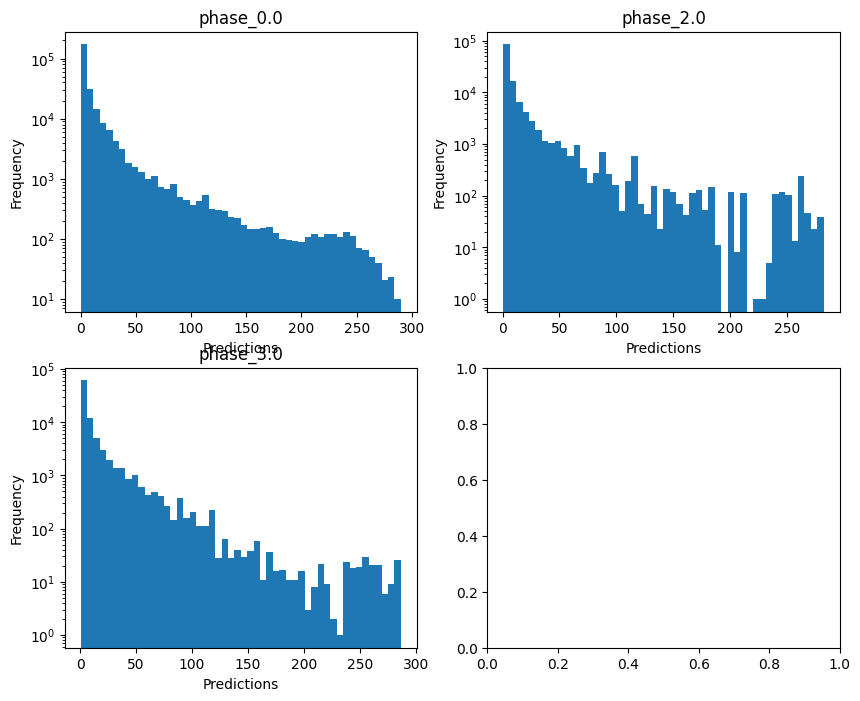

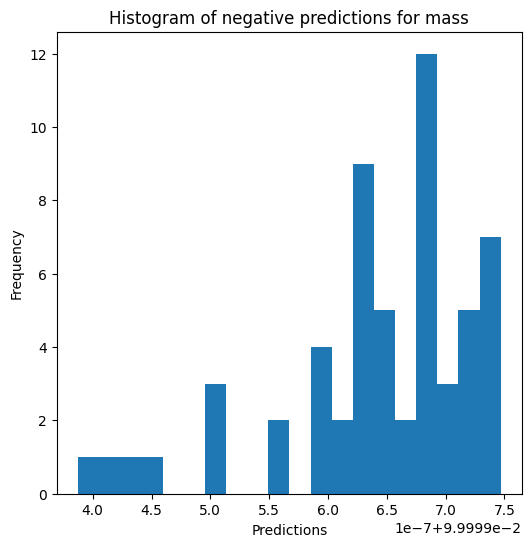


radius results for the phase category with a value of 0.0
  value range :  -0.9974628481553472 - 3.0827540579576227
  RVE :  0.9999459020923055
  RMSE :  0.004194675359778996
  MAE :  0.0020882960748264488
  MedAE :  0.001018233403052668
  CORR :  0.9999729881935343
  MAX_ER :  0.40201371573545996
  Percentiles : 
    75th percentile :  0.0023307052311380763
    90th percentile :  0.0048407692105750365
    95th percentile :  0.007520106267244442
    99th percentile :  0.016463197464359706

radius results for the phase category with a value of 2.0
  value range :  0.0919862423867022 - 2.891706235288321
  RVE :  0.9999328206795431
  RMSE :  0.004050433670472076
  MAE :  0.002678835895263072
  MedAE :  0.0017526159288088206
  CORR :  0.9999670582449236
  MAX_ER :  0.08662048149551471
  Percentiles : 
    75th percentile :  0.0035715025392952793
    90th percentile :  0.006154090767002396
    95th percentile :  0.00820905655772508
    99th percentile :  0.014216237936738553

radius result

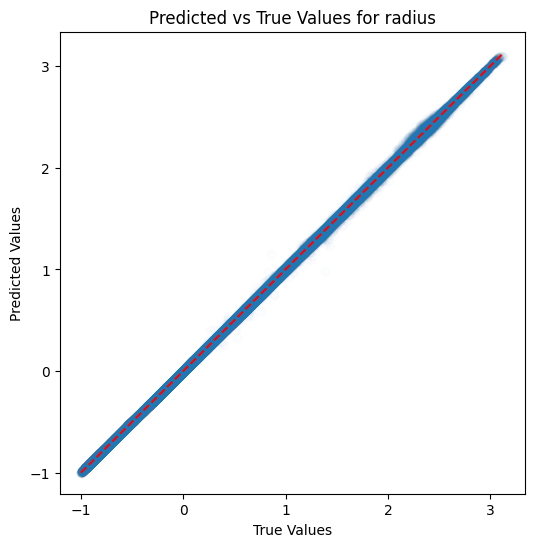

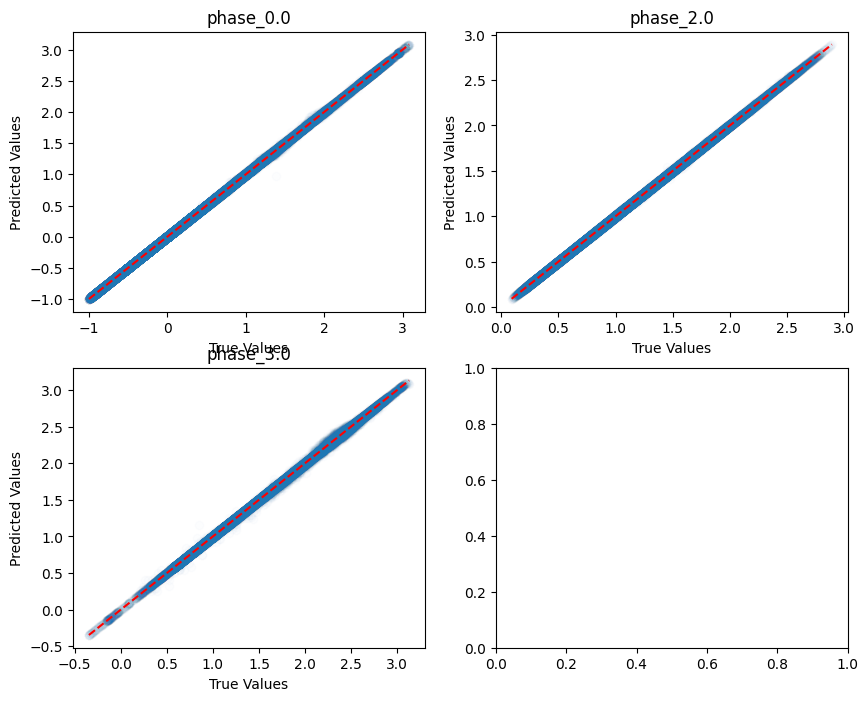

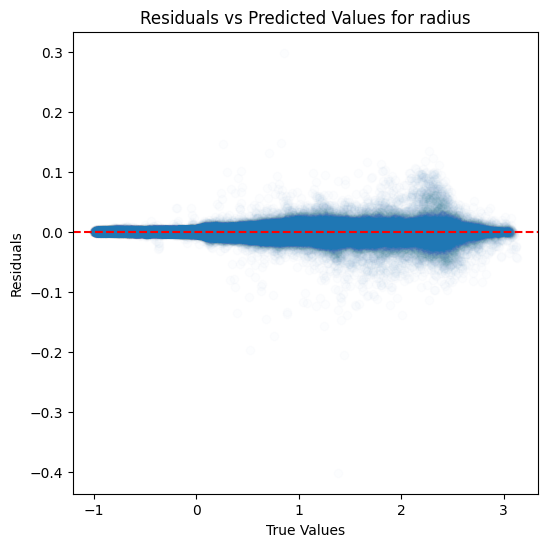

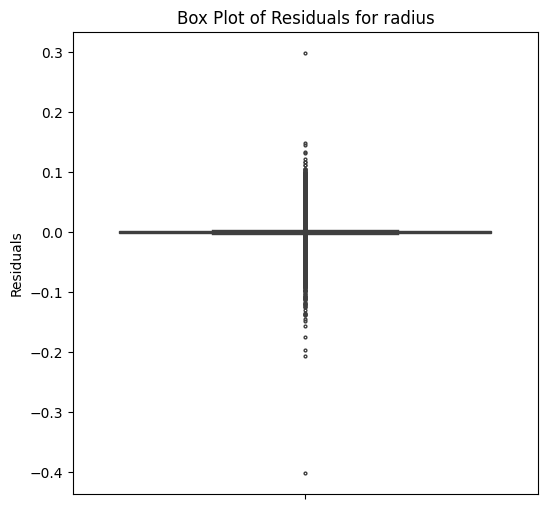

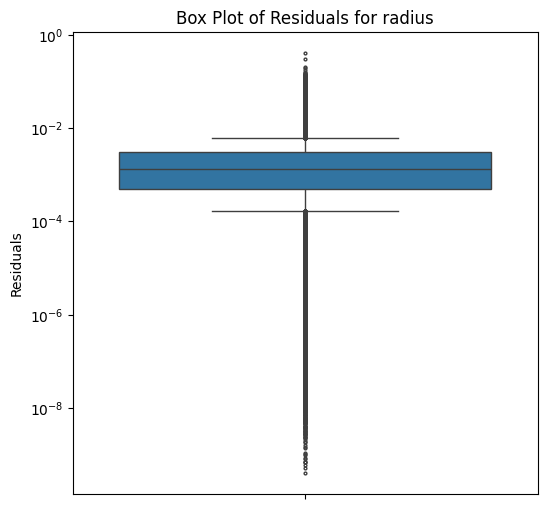

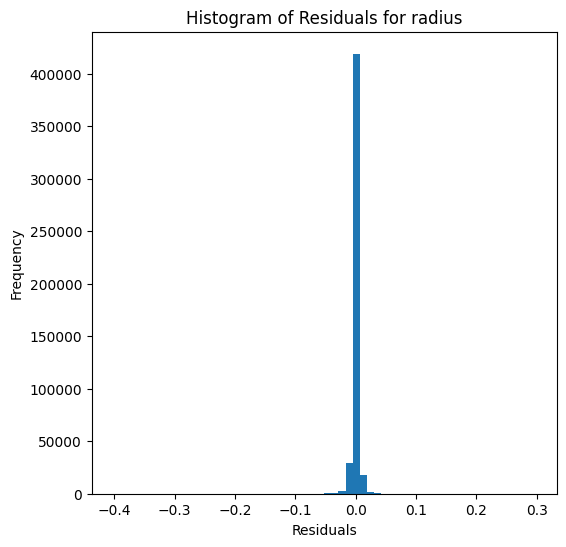

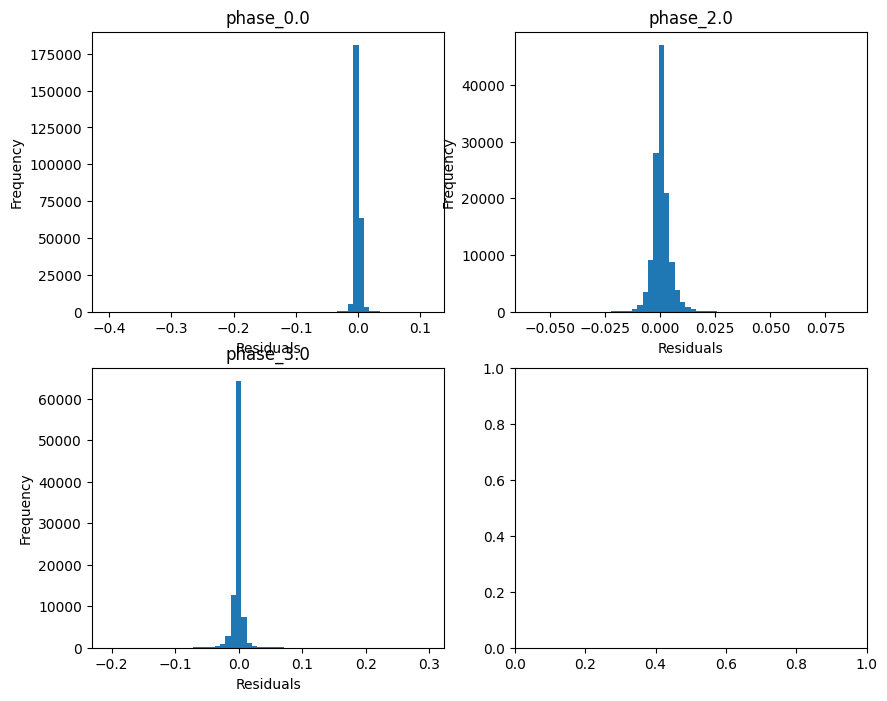

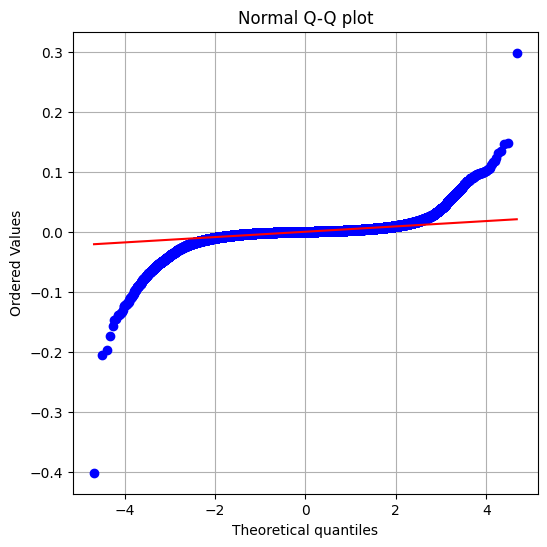

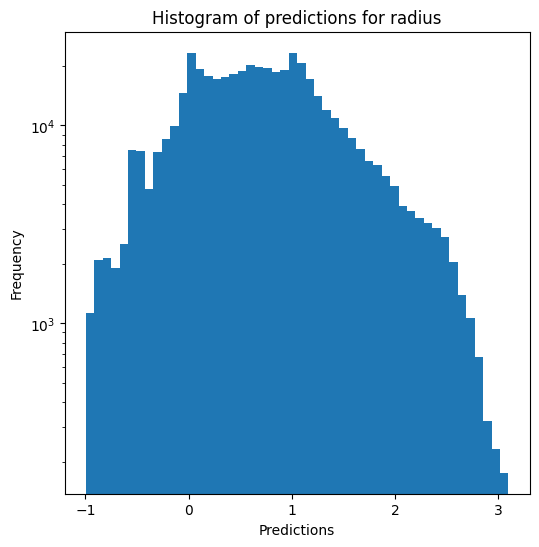

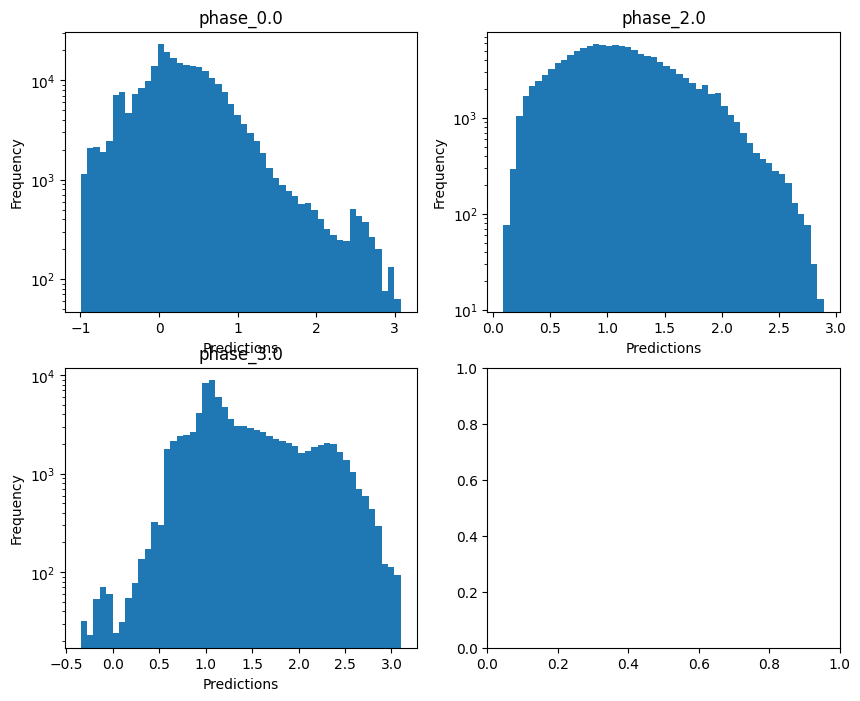

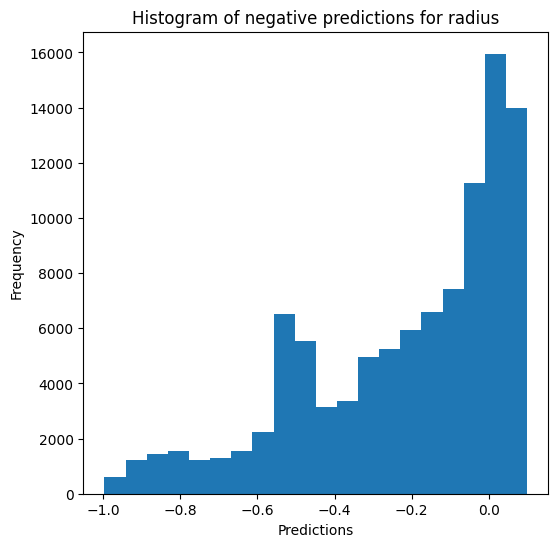

Saving predictions and results...


In [34]:
rf_evaluator.evaluate_Kfold_results(RandomForestRegressor, X_train, y_train, categories_train, categories_name, path_to_predictions, tag, random_state=12, override=override, use_preds=use_preds, save=save, show=show, scaler_name=scaler_name, n_jobs=5)
# average depth de 44-46

### XGBoost

In [35]:
xgb_evaluator = Model_evaluator("xgboost", path=path_to_results, physical_model=physical_model, output_parameters=output_parameters)


scale_standard train data :
Performing K-fold...
Split 1 X_train [[ 7.15        3.53089845  0.15829325  0.5       ]
 [ 8.2         3.89917649  2.70415485 -1.        ]
 [ 7.8         3.94176332  2.27404942 -2.        ]
 ...
 [10.05        3.63306806  5.06081841 -3.        ]
 [10.1         3.63517608  4.85026786 -1.5       ]
 [ 7.6         4.34799155  3.56572608 -4.        ]]
X_train_scaled [[-0.74966014 -1.43942188 -2.75434164  1.40814104]
 [ 0.06732518 -0.37487749 -0.66099847  0.28021372]
 [-0.24390732 -0.25177601 -1.01465408 -0.47173783]
 ...
 [ 1.5067755  -1.14409043  1.27677598 -1.22368938]
 [ 1.54567956 -1.13799698  1.10365009 -0.09576206]
 [-0.39952358  0.92246718  0.04743134 -1.97564093]]
2 X_train [[ 7.15        3.53089845  0.15829325  0.5       ]
 [ 8.2         3.89917649  2.70415485 -1.        ]
 [ 7.8         3.94176332  2.27404942 -2.        ]
 ...
 [10.05        3.63306806  5.06081841 -3.        ]
 [10.1         3.63517608  4.85026786 -1.5       ]
 [ 7.6         4.34799155

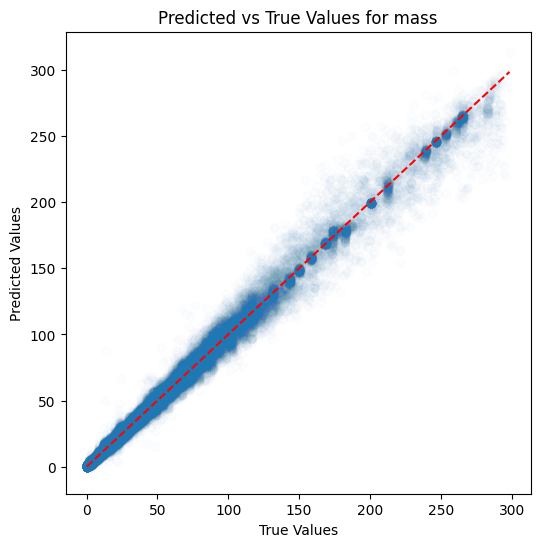

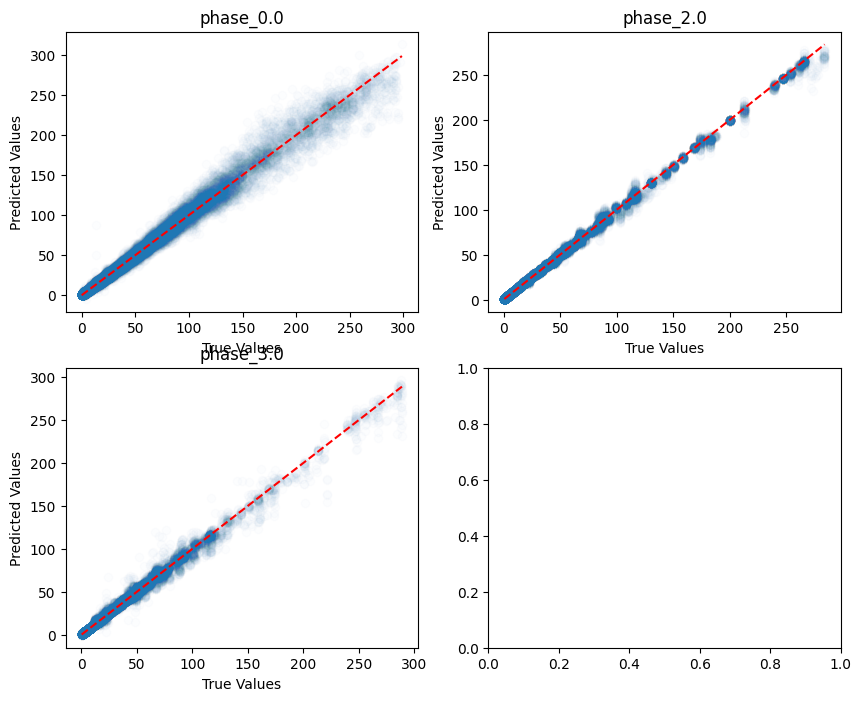

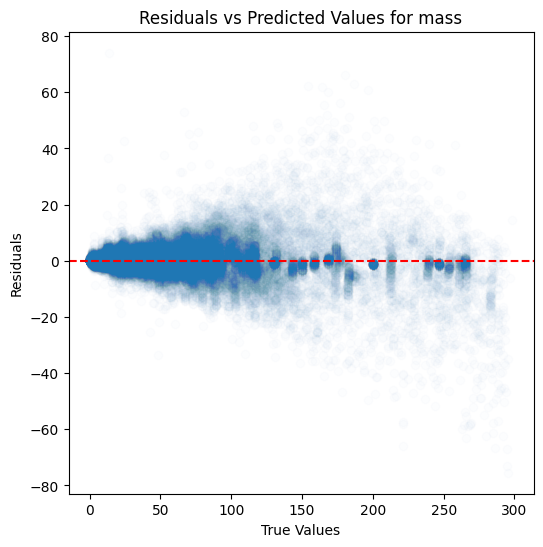

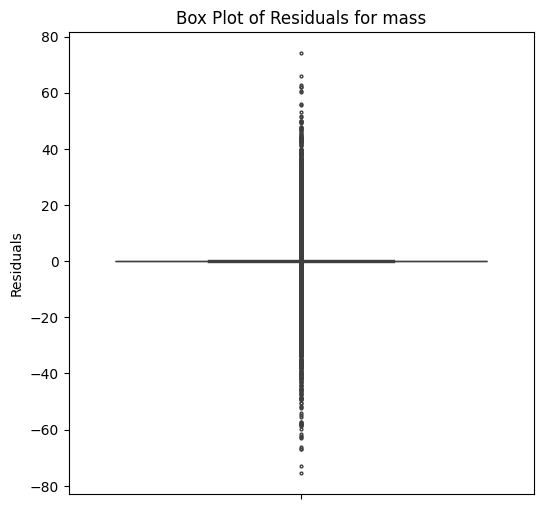

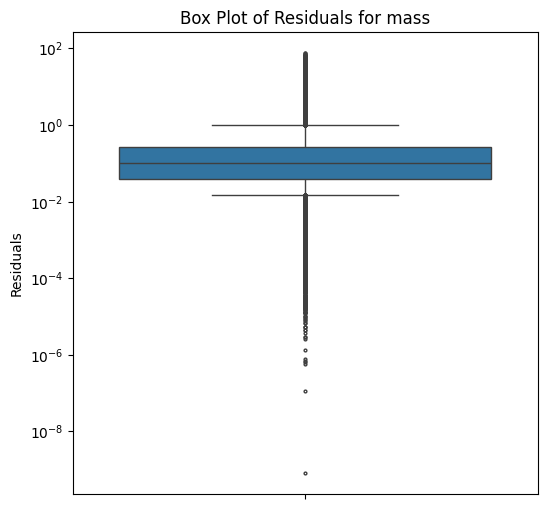

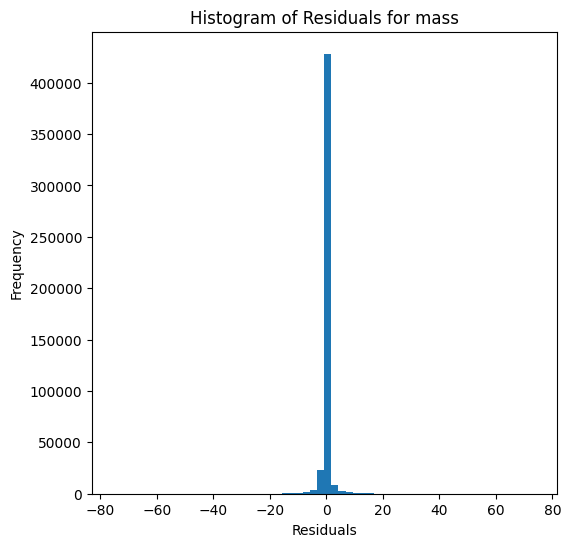

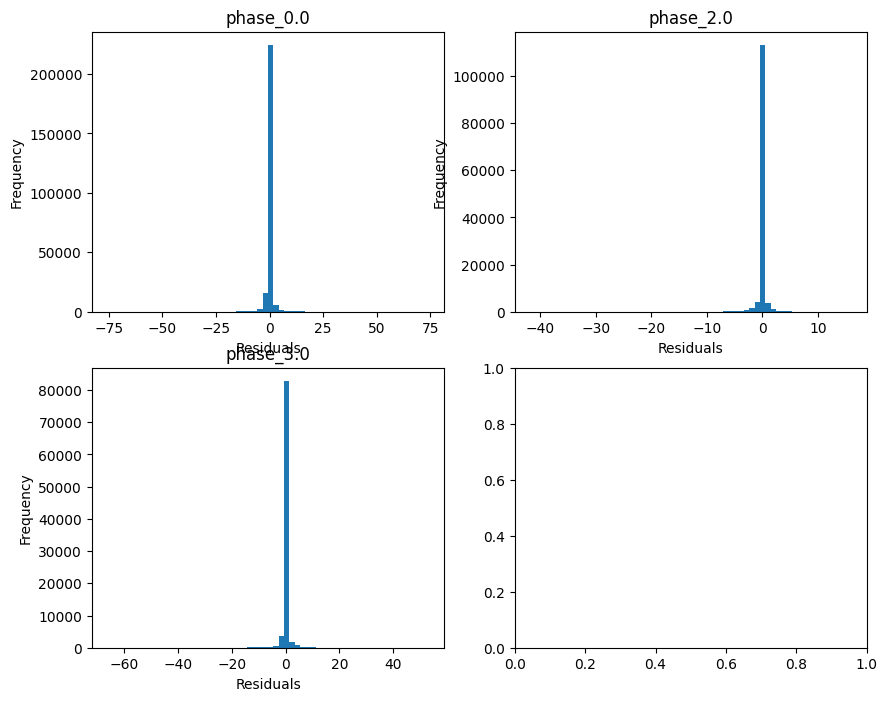

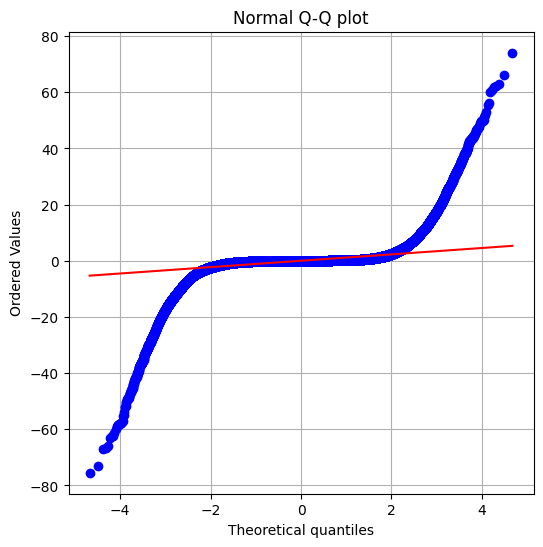

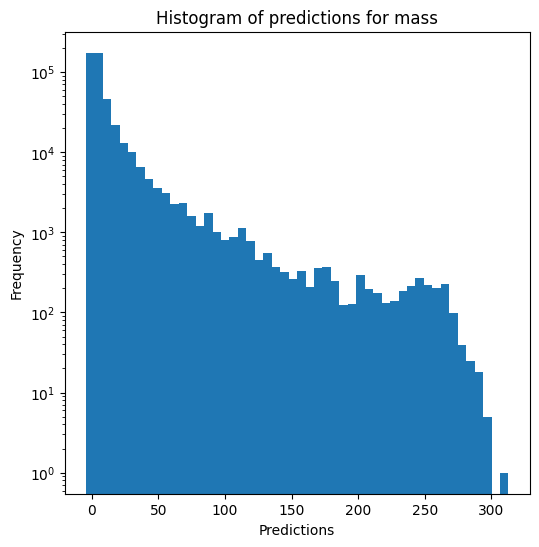

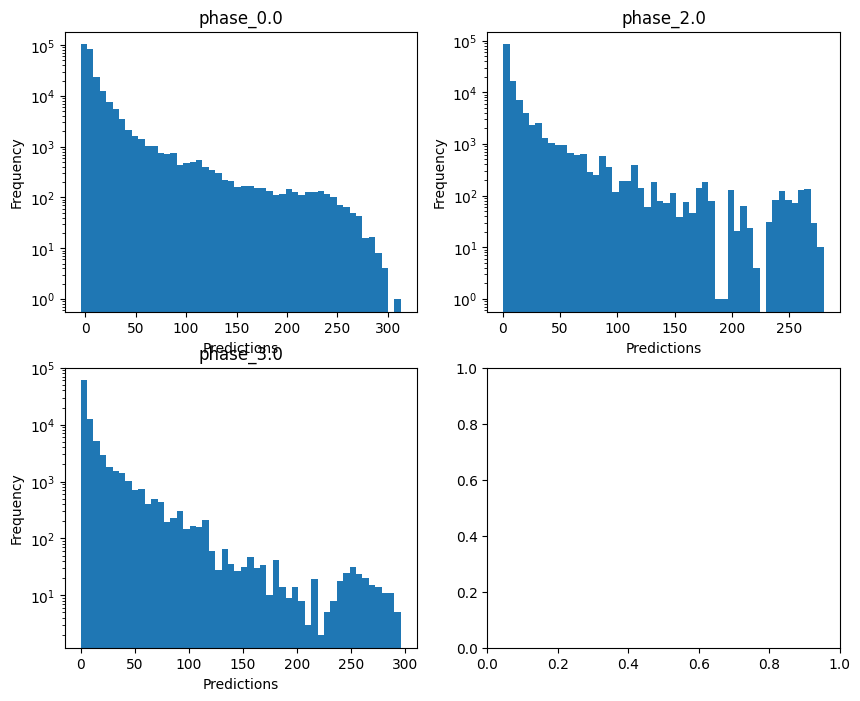

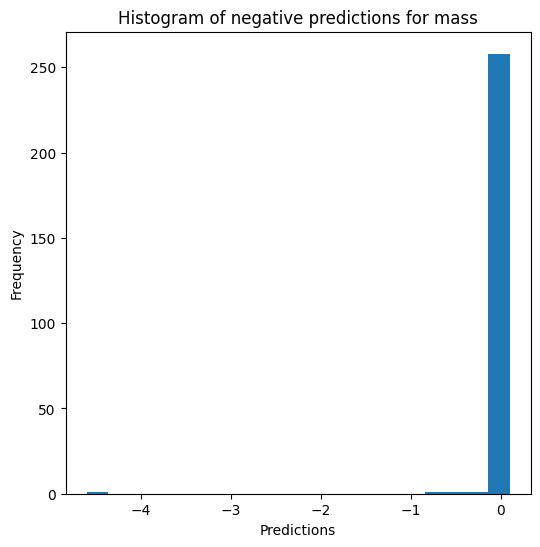


radius results for the phase category with a value of 0.0
  value range :  -0.9974628481553472 - 3.0827540579576227
  RVE :  0.9994418047471755
  RMSE :  0.0134739207307733
  MAE :  0.009913963547642025
  MedAE :  0.007483076130594041
  CORR :  0.9997209009793395
  MAX_ER :  0.13027270034423255
  Percentiles : 
    75th percentile :  0.013605134614645492
    90th percentile :  0.021551585886708798
    95th percentile :  0.027520282863635292
    99th percentile :  0.04199129077825983

radius results for the phase category with a value of 2.0
  value range :  0.0919862423867022 - 2.891706235288321
  RVE :  0.9992137759915166
  RMSE :  0.013775233797365899
  MAE :  0.010751880110919912
  MedAE :  0.008825309783412005
  CORR :  0.9996073362568038
  MAX_ER :  0.08399605101989271
  Percentiles : 
    75th percentile :  0.015254971388617283
    90th percentile :  0.022526507912957832
    95th percentile :  0.02741850393752362
    99th percentile :  0.03826439298979589

radius results for the

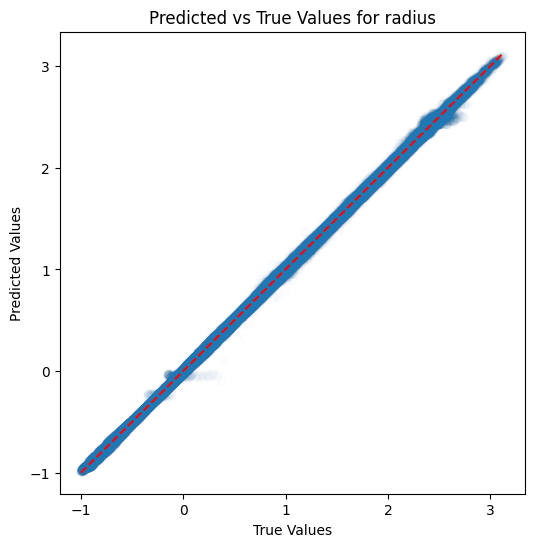

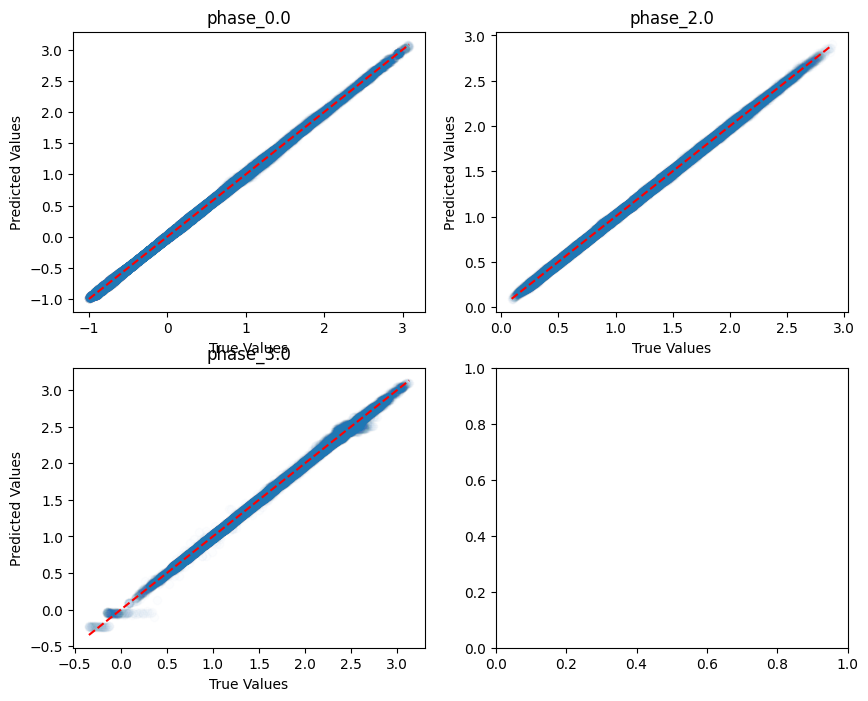

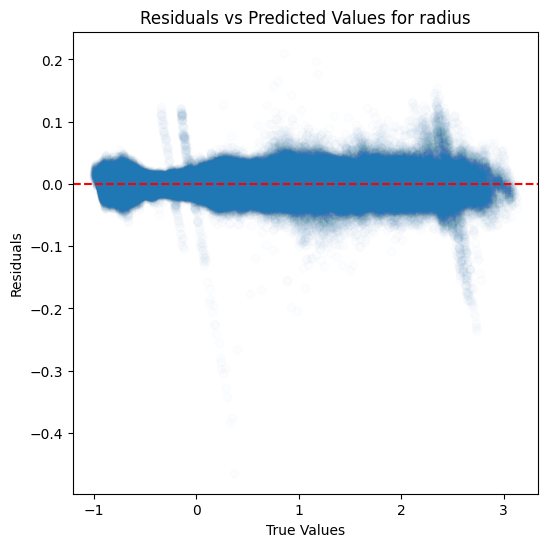

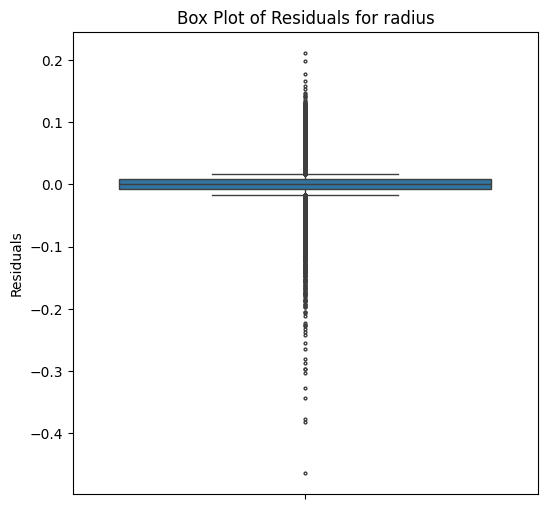

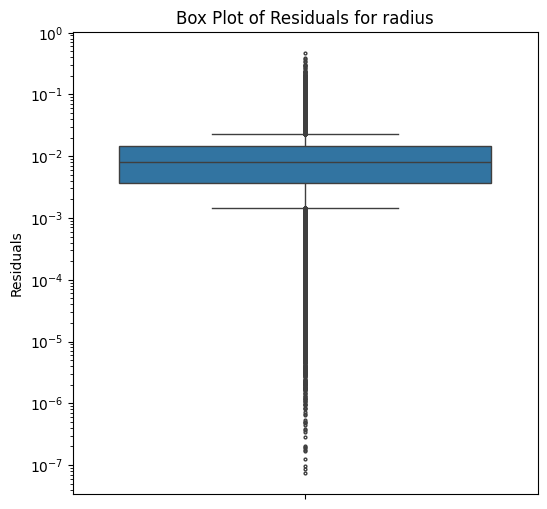

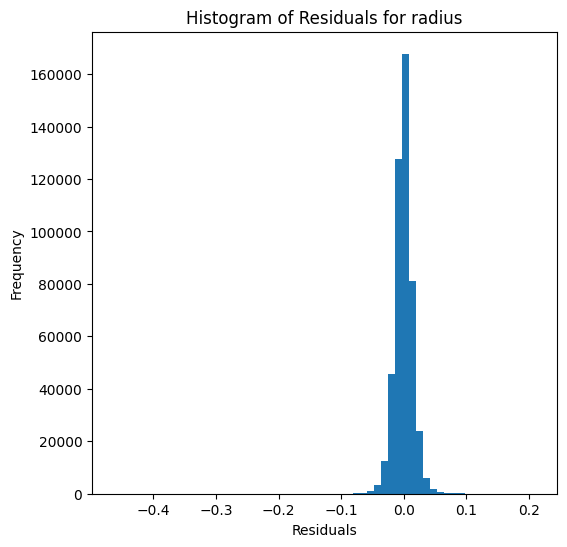

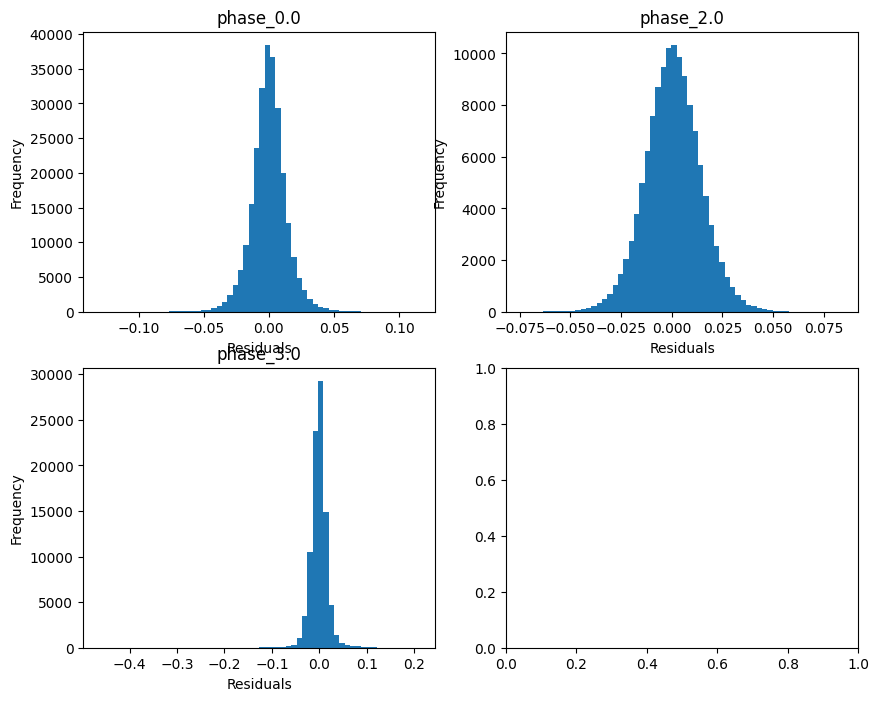

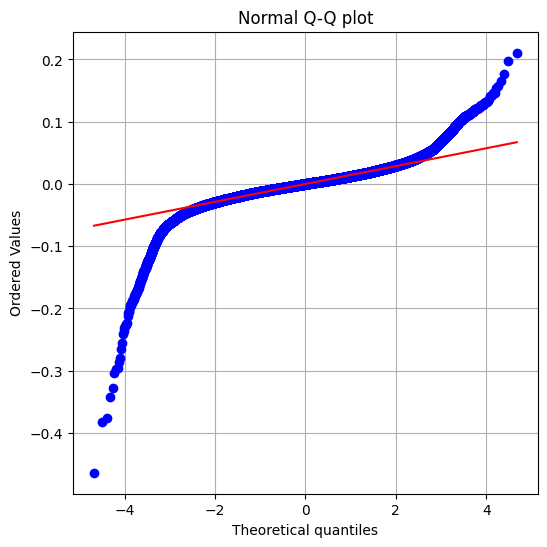

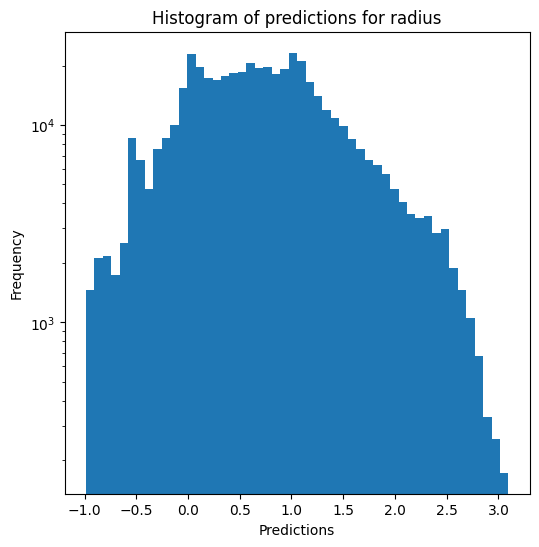

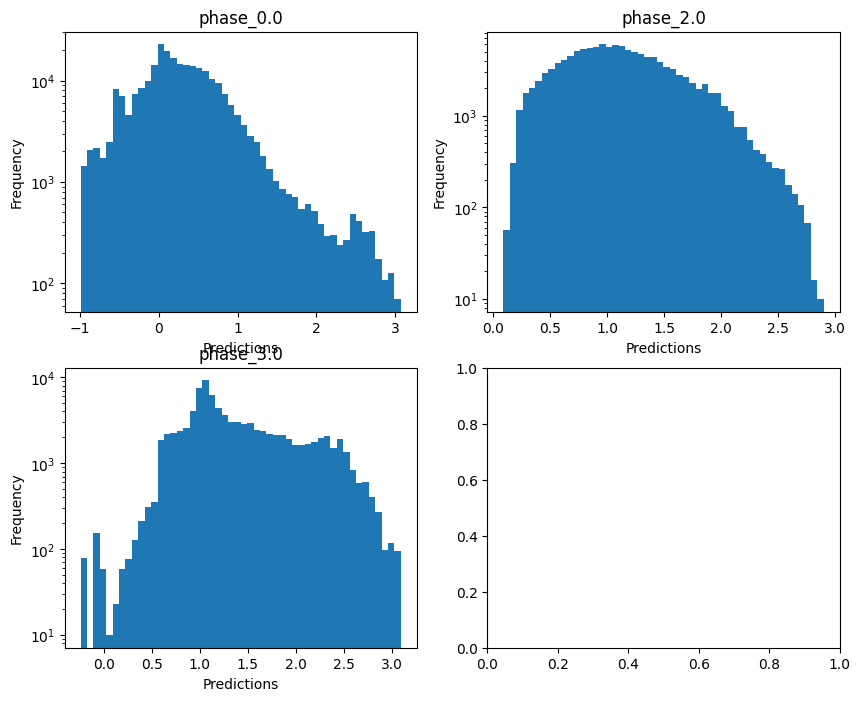

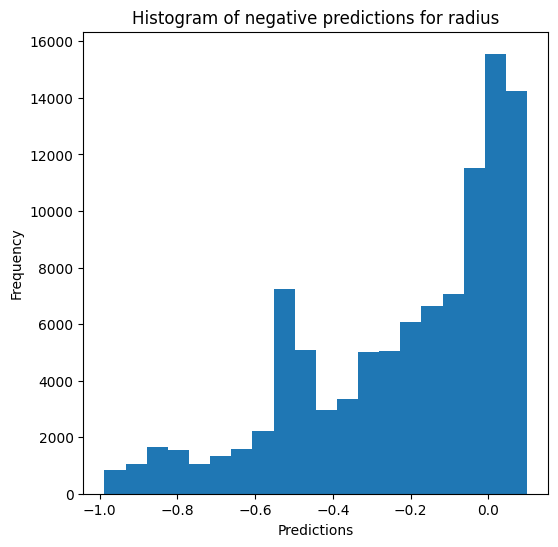

Saving predictions and results...


In [36]:
xgb_evaluator.evaluate_Kfold_results(XGBRegressor, X_train, y_train, categories_train, categories_name, path_to_predictions, tag, random_state=12, override=override, use_preds=use_preds, save=save, show=show, scaler_name=scaler_name, n_jobs=5)

### Multi-layer perceptron

In [37]:
mlp_evaluator = Model_evaluator("mlp", path=path_to_results, physical_model=physical_model, output_parameters=output_parameters)


scale_standard train data :
Performing K-fold...
Split 1 X_train [[ 7.15        3.53089845  0.15829325  0.5       ]
 [ 8.2         3.89917649  2.70415485 -1.        ]
 [ 7.8         3.94176332  2.27404942 -2.        ]
 ...
 [10.05        3.63306806  5.06081841 -3.        ]
 [10.1         3.63517608  4.85026786 -1.5       ]
 [ 7.6         4.34799155  3.56572608 -4.        ]]
X_train_scaled [[-0.74874196 -1.44027875 -2.7555661   1.40899024]
 [ 0.06845527 -0.3756566  -0.66141484  0.28103766]
 [-0.24285796 -0.25254612 -1.01520698 -0.47093073]
 ...
 [ 1.50827896 -1.14492573  1.27710764 -1.22289912]
 [ 1.54719311 -1.13883184  1.10391492 -0.09494654]
 [-0.39851458  0.92178286  0.04728844 -1.97486751]]


c:\Users\antoi\Code\unif\MA2\thesis\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(


0.9433464633859399
2 X_train [[ 7.15        3.53089845  0.15829325  0.5       ]
 [ 7.8         3.94176332  2.27404942 -2.        ]
 [10.25        3.75897192  2.59813882 -1.        ]
 ...
 [ 8.65        3.77176074  4.43996995  0.25      ]
 [10.1         3.63517608  4.85026786 -1.5       ]
 [ 7.6         4.34799155  3.56572608 -4.        ]]
X_train_scaled [[-0.75121967 -1.43973294 -2.7566416   1.4099741 ]
 [-0.24552615 -0.25145163 -1.01607936 -0.46983437]
 [ 1.66054941 -0.78011109 -0.74946179  0.28208902]
 ...
 [ 0.41576537 -0.74312396  0.76575143  1.22199325]
 [ 1.5438509  -1.13814677  1.10328987 -0.09387268]
 [-0.40112416  0.92341983  0.04654007 -1.97368114]]


c:\Users\antoi\Code\unif\MA2\thesis\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(


0.7830873071398552
3 X_train [[ 8.2         3.89917649  2.70415485 -1.        ]
 [ 8.35        3.72220169  4.81986634 -3.        ]
 [ 7.65        4.13832451  2.96071708 -1.5       ]
 ...
 [10.05        3.63306806  5.06081841 -3.        ]
 [10.1         3.63517608  4.85026786 -1.5       ]
 [ 7.6         4.34799155  3.56572608 -4.        ]]
X_train_scaled [[ 0.06552198 -0.37452345 -0.66195002  0.28114349]
 [ 0.1821968  -0.88637046  1.0779912  -1.22459484]
 [-0.36228569  0.31714114 -0.45095566 -0.09529109]
 ...
 [ 1.50451142 -1.14416299  1.27614791 -1.22459484]
 [ 1.54340302 -1.13806616  1.10299312 -0.09529109]
 [-0.4011773   0.92354073  0.04659805 -1.977464  ]]


...

0.7757900718389156
4 X_train [[ 7.15        3.53089845  0.15829325  0.5       ]
 [ 8.2         3.89917649  2.70415485 -1.        ]
 [ 7.8         3.94176332  2.27404942 -2.        ]
 ...
 [ 8.65        3.77176074  4.43996995  0.25      ]
 [10.05        3.63306806  5.06081841 -3.        ]
 [ 7.6         4.34799155  3.56572608 -4.        ]]
X_train_scaled [[-0.75266821 -1.43835532 -2.7515237   1.40746183]
 [ 0.06447422 -0.37283416 -0.65998779  0.27943903]
 [-0.24681813 -0.24961972 -1.01333808 -0.47257617]
 ...
 [ 0.41467812 -0.74148002  0.76605974  1.21945803]
 [ 1.50420135 -1.14275289  1.27611371 -1.22459138]
 [-0.40246431  0.9257009   0.04783041 -1.97660658]]


c:\Users\antoi\Code\unif\MA2\thesis\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(


0.7907476437986805
5 X_train [[ 7.15        3.53089845  0.15829325  0.5       ]
 [ 8.2         3.89917649  2.70415485 -1.        ]
 [ 7.8         3.94176332  2.27404942 -2.        ]
 ...
 [ 9.6         3.4996212   5.2088761  -0.25      ]
 [10.05        3.63306806  5.06081841 -3.        ]
 [10.1         3.63517608  4.85026786 -1.5       ]]
X_train_scaled [[-0.75107389 -1.43904962 -2.75499088  1.40819626]
 [ 0.0657979  -0.37433543 -0.66147566  0.27980394]
 [-0.24539136 -0.25121431 -1.01516035 -0.4724576 ]
 ...
 [ 1.15496029 -1.52947404  1.39820899  0.8440001 ]
 [ 1.5050482  -1.14367106  1.27645805 -1.22471915]
 [ 1.54394686 -1.13757665  1.10331794 -0.09632683]]


c:\Users\antoi\Code\unif\MA2\thesis\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(


0.9298917576400461

Evaluating predictions...

mass results for the phase category with a value of 0.0
  value range :  0.0999979840073621 - 298.5447575808816
  RVE :  0.9838312171208503
  RMSE :  3.345417147788434
  MAE :  0.7869303228709875
  MedAE :  0.13326431997162713
  CORR :  0.9919889807862203
  MAX_ER :  114.63837176094015
  Percentiles : 
    75th percentile :  0.4026302552080129
    90th percentile :  1.386848398332542
    95th percentile :  3.3821442010378093
    99th percentile :  11.685002063342123

mass results for the phase category with a value of 2.0
  value range :  0.6538581961218565 - 283.72102985530483
  RVE :  0.9953629704832989
  RMSE :  2.0307284138324713
  MAE :  0.6482718898189876
  MedAE :  0.16562279458809126
  CORR :  0.9977086617208759
  MAX_ER :  54.87667123502186
  Percentiles : 
    75th percentile :  0.39578294605773756
    90th percentile :  1.2901344162117228
    95th percentile :  2.7401524026518893
    99th percentile :  9.88222246089119

mass res

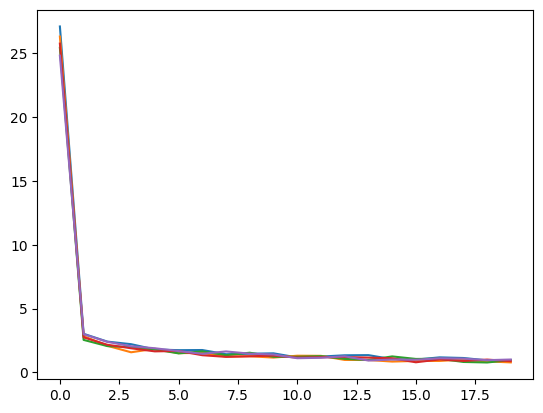

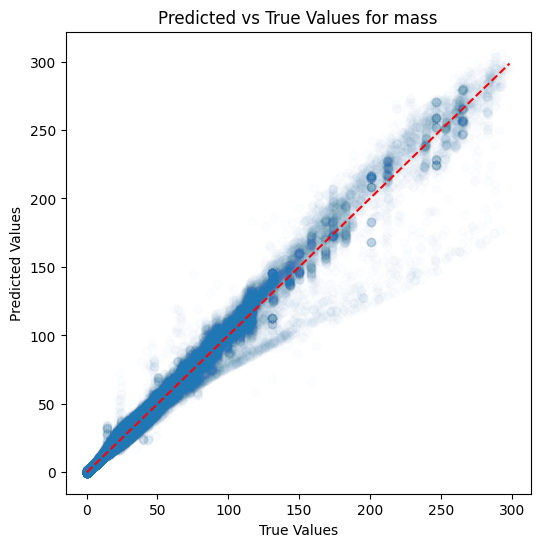

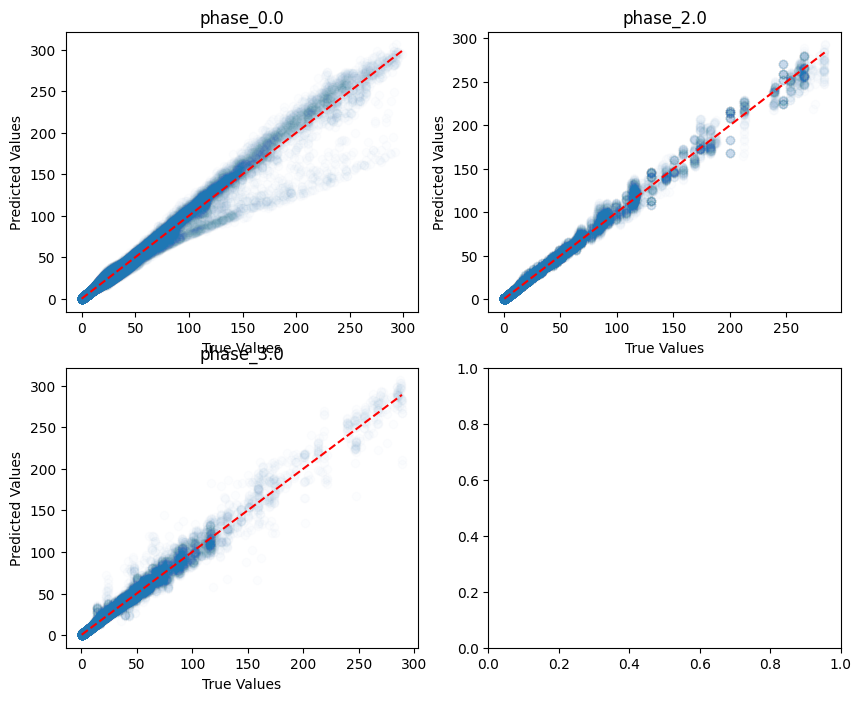

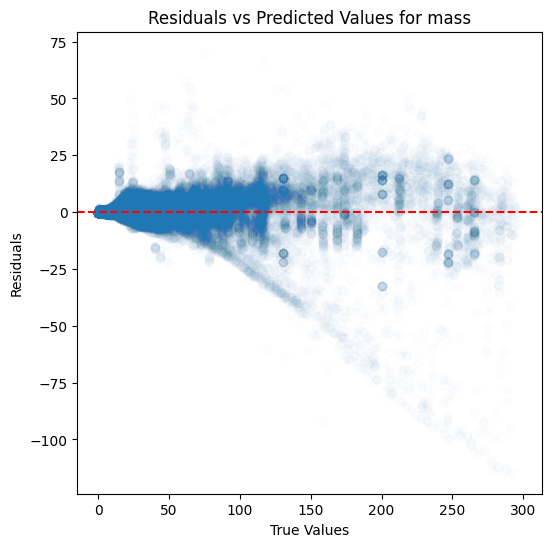

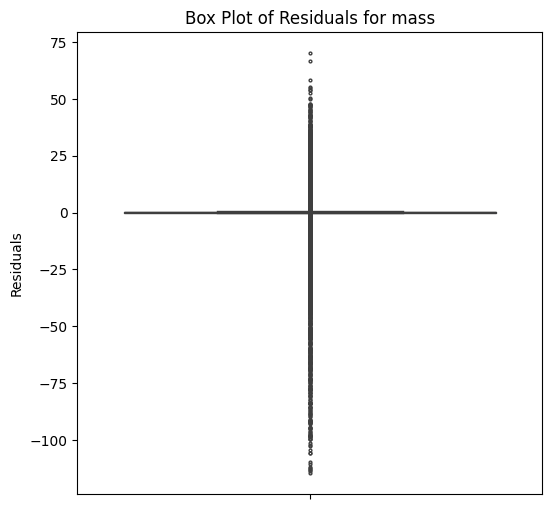

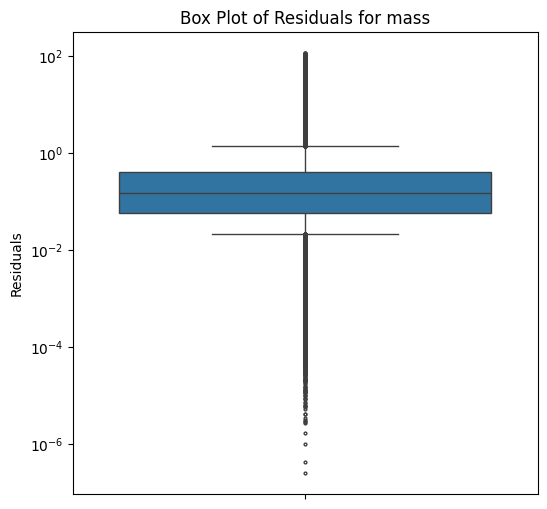

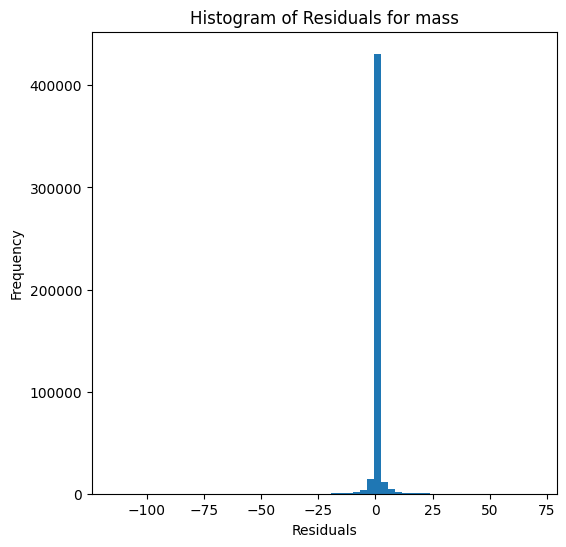

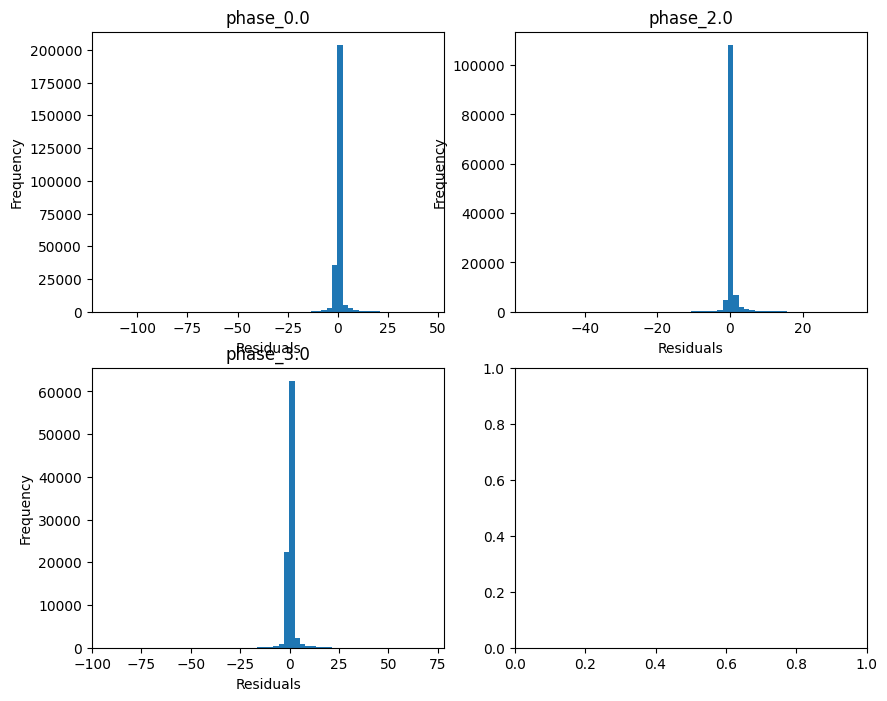

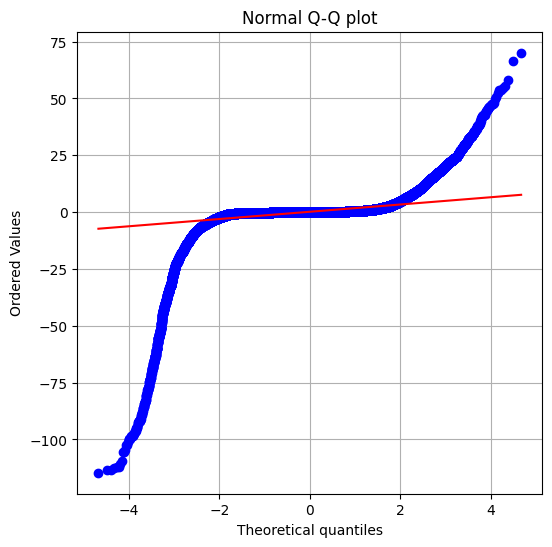

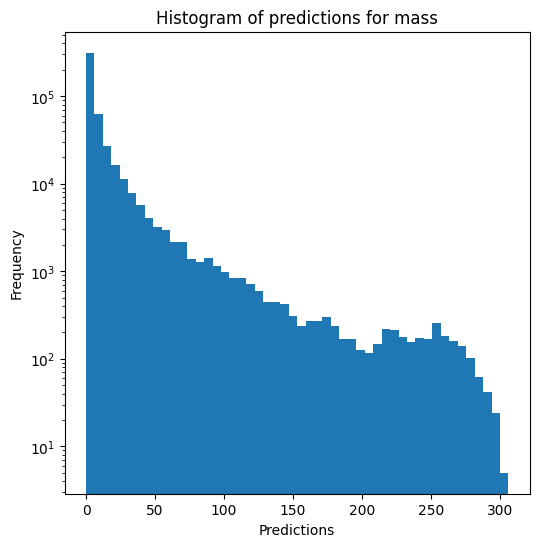

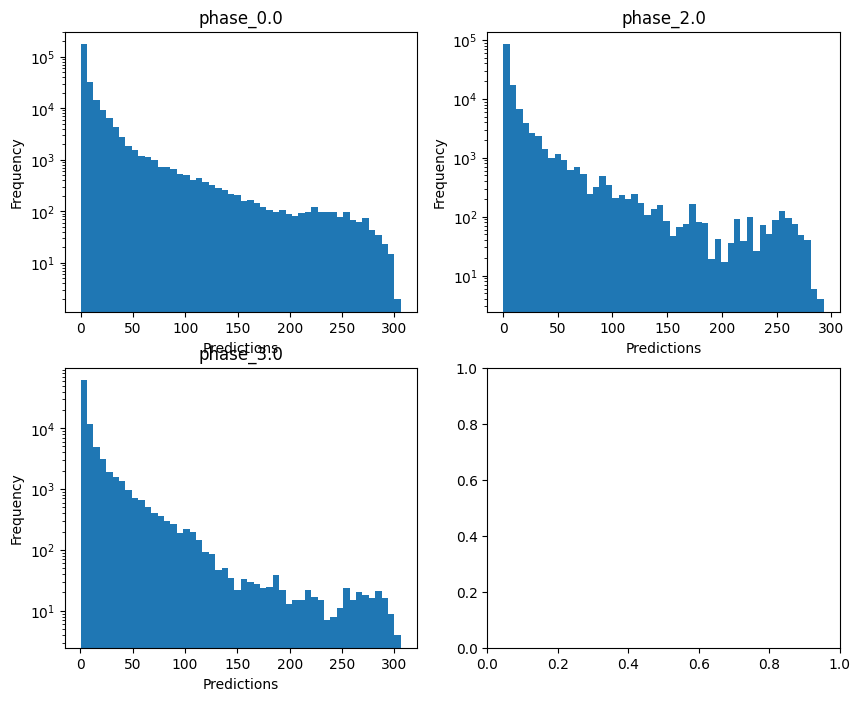

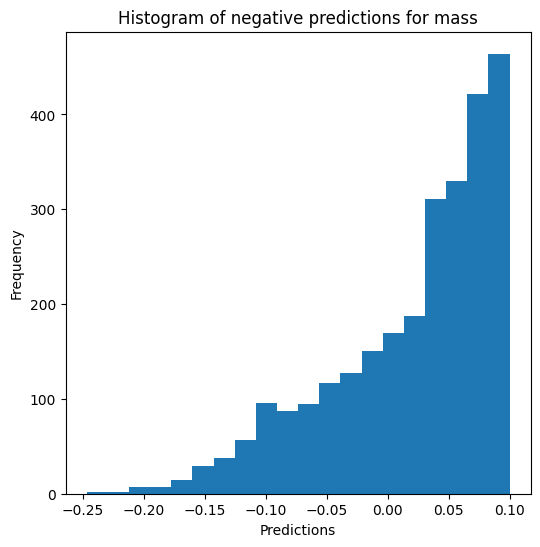


radius results for the phase category with a value of 0.0
  value range :  -0.9974628481553472 - 3.0827540579576227
  RVE :  0.9878229223304492
  RMSE :  0.06327959715985819
  MAE :  0.04810172440888462
  MedAE :  0.03775620031257576
  CORR :  0.9942533582095376
  MAX_ER :  0.5541350334040471
  Percentiles : 
    75th percentile :  0.06763427917462972
    90th percentile :  0.10229113393788443
    95th percentile :  0.12812812063209622
    99th percentile :  0.18560805195826338

radius results for the phase category with a value of 2.0
  value range :  0.0919862423867022 - 2.891706235288321
  RVE :  0.9870578755187476
  RMSE :  0.05602295133803331
  MAE :  0.04311831752282916
  MedAE :  0.03507827858339008
  CORR :  0.9939664670939565
  MAX_ER :  0.3701832932675224
  Percentiles : 
    75th percentile :  0.06077720947309939
    90th percentile :  0.08906056056658264
    95th percentile :  0.10882074933265266
    99th percentile :  0.15997705231293677

radius results for the phase cate

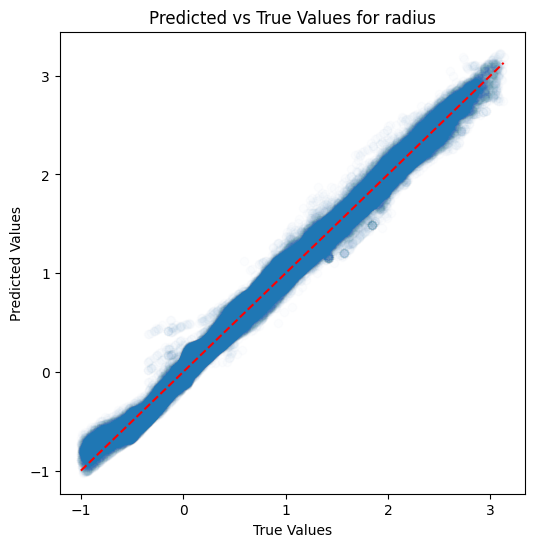

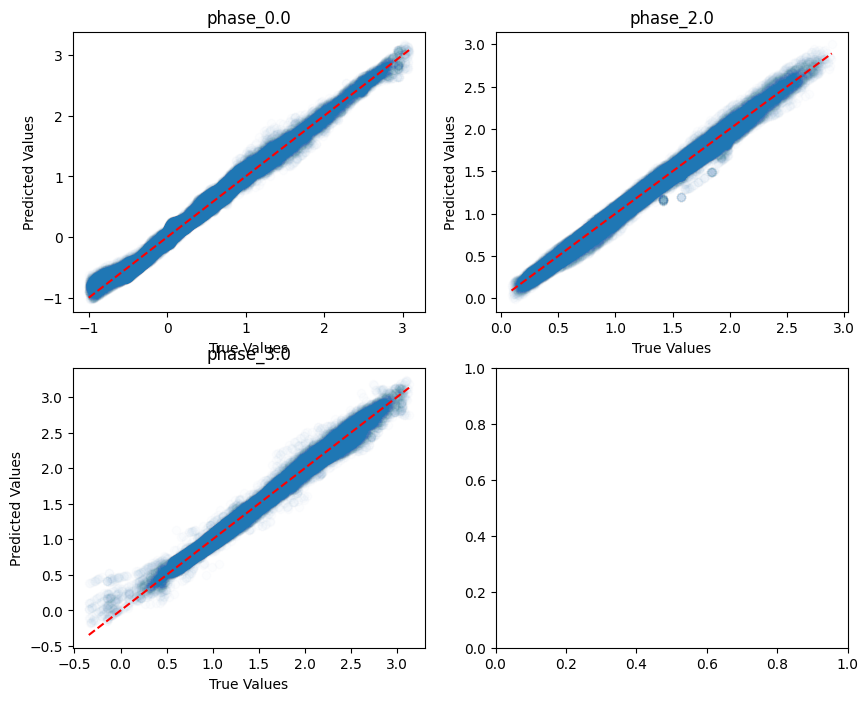

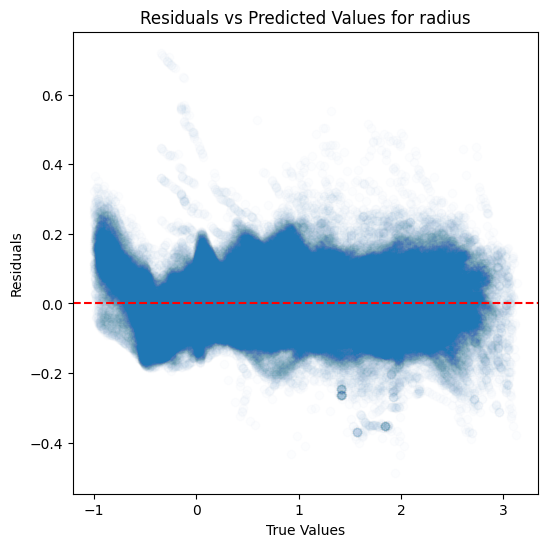

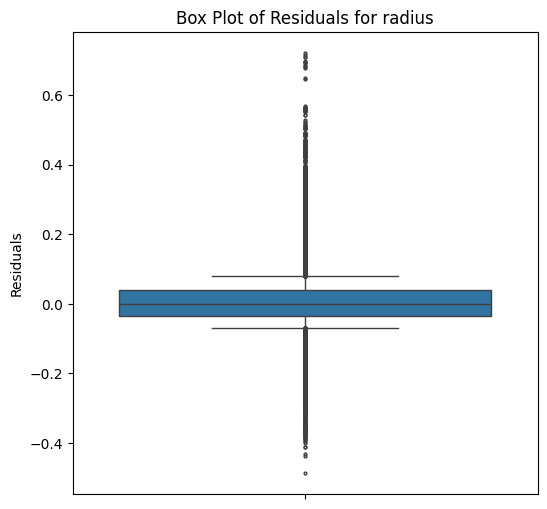

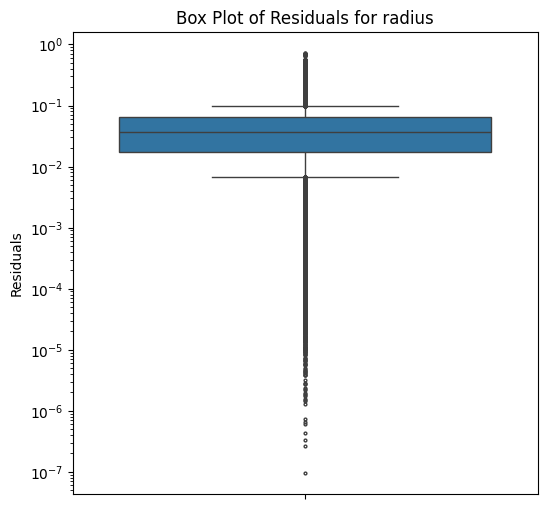

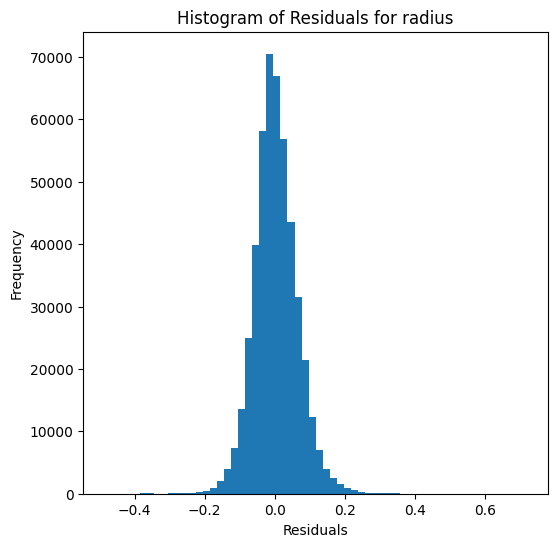

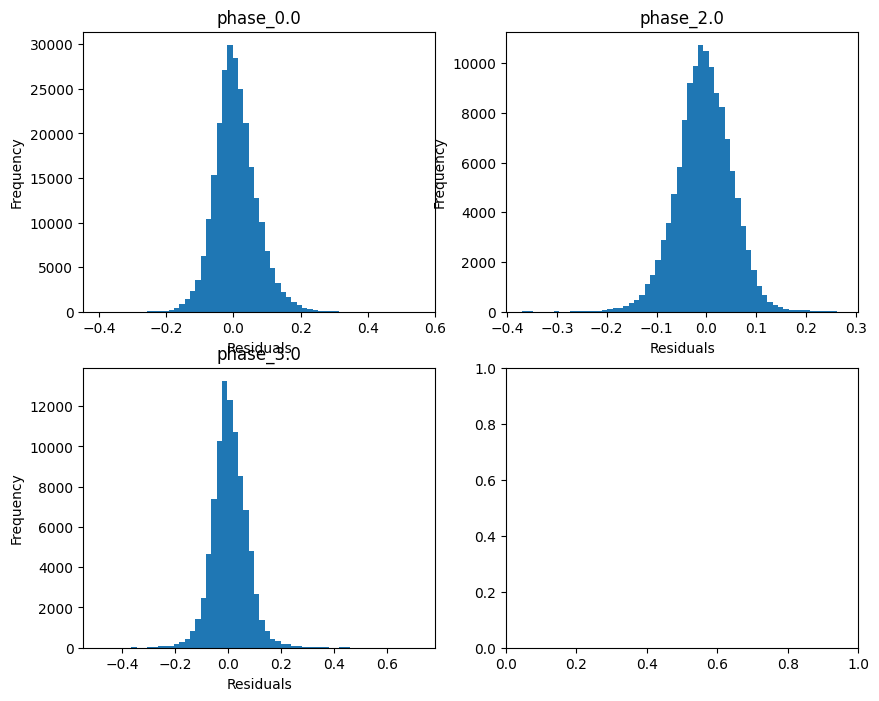

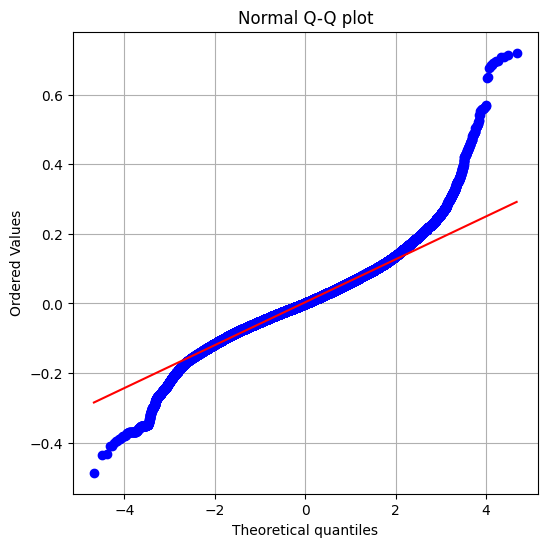

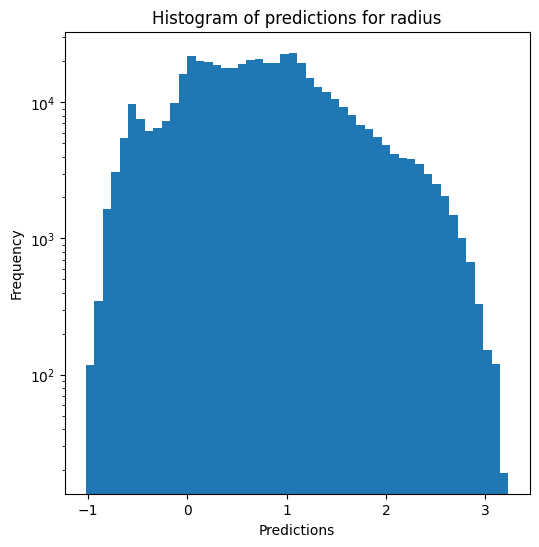

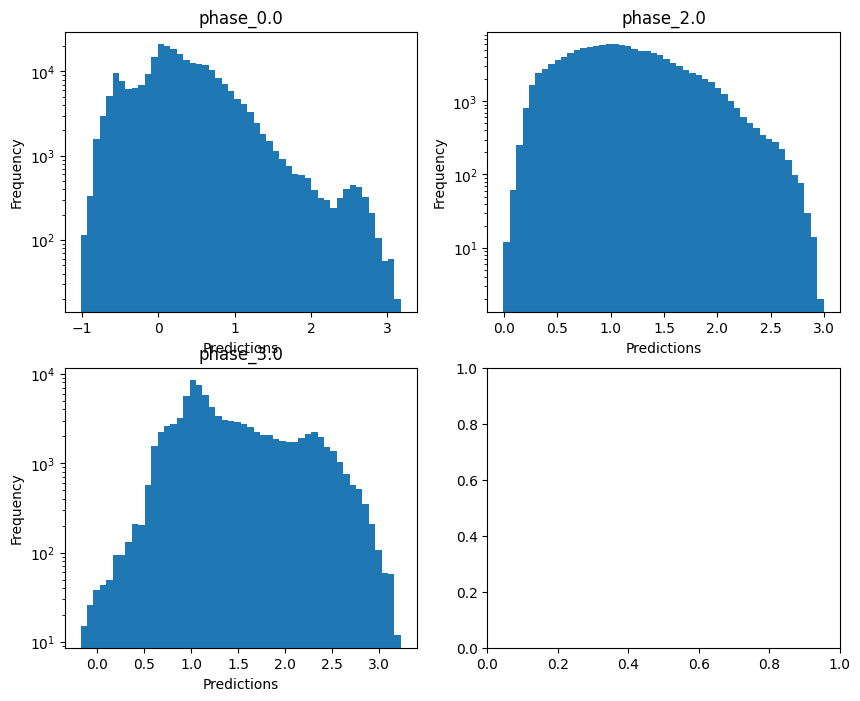

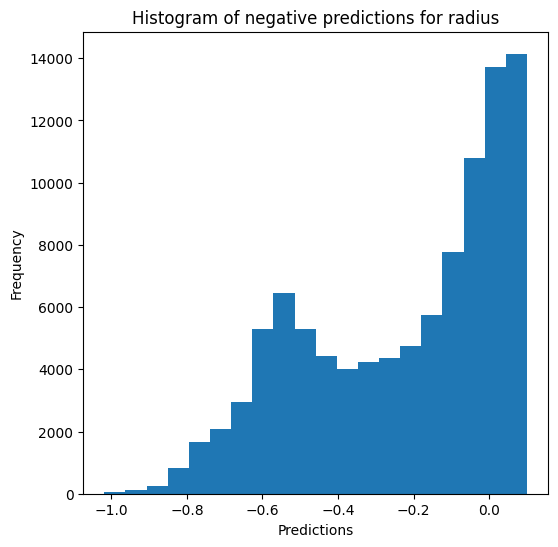

Saving predictions and results...


In [38]:
mlp_evaluator.evaluate_Kfold_results(MLPRegressor, X_train, y_train, categories_train, categories_name, path_to_predictions, tag, n_splits=5, random_state=12, override=override, use_preds=use_preds, save=save, show=show, scaler_name=scaler_name,
                                      hidden_layer_sizes = (100, 100, 100, 100), max_iter=20, batch_size=400)

Avec batch_size=auto (200):

plus de 30 minutes pour entrainer un seul split de Kfold avec les paramètres par défaut (1 hidden layer de taille 100)

plus de 15 minutes pour entrainer un seul split de Kfold avec les 1 hidden layer de taille 10

- et max_iter=20, hidden_layer_sizes=(100, 50, 25): ~5 minutes par fold (plutôt bon résultats)
- et max_iter=20, hidden_layer_sizes=(100, 100, 100): ~5 minutes par fold

Avec batch_size=400:


Avec learning_rate= :


hidden_layer_sizes = (100, 100), max_iter=20, batch_size=200 => 17 min pour 2 splits et min_loss de 2.1
RMSE = RVE :  0.984867927459382
RMSE :  2.5335132759292107
MAE :  0.7276983504493552
MedAE :  0.3034009994265745
CORR :  0.9927285673947535
MAX_ER :  169.74348568157313
Percentiles : 75th percentile :  0.5113604728134682 90th percentile :  1.1025928446049704 95th percentile :  2.1347654852226015 99th percentile :  9.897101952249908)

hidden_layer_sizes = (100, 100), max_iter=20, batch_size=400 => 7 min pour 2 splits et min_loss de 2.2
RVE :  0.9797171492755655
RMSE :  2.983208723004754
MAE :  0.9125599339275378
MedAE :  0.43124518658659683
CORR :  0.9920536596906272
MAX_ER :  170.53076478793002
Percentiles : 75th percentile :  0.675744507049632 90th percentile :  1.2421052024331438 95th percentile :  2.441733387262636 99th percentile :  11.925724226452427

hidden_layer_sizes = (100, 100), max_iter=20, batch_size=800 => 3 min pour 2 splits et min_loss de 2.3 et 2.7

hidden_layer_sizes = (100, 100), max_iter=20, batch_size=1600 => 3 min 30 pour 2 splits et min_loss de 7.8 et 3.8

=> batch_size plus grand == plus rapide mais moins bon